In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_consommations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")
df_reclamations = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")

PermissionError: Forbidden

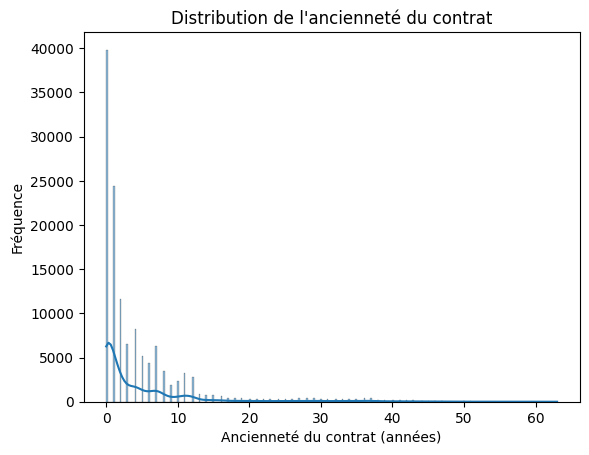

In [ ]:
sns.histplot(df_portefeuille["client_anciennete_contrat_annees"], kde=True)
plt.xlabel("Ancienneté du contrat (années)")
plt.ylabel("Fréquence")
plt.title("Distribution de l'ancienneté du contrat")
plt.show()

In [ ]:
df_portefeuille["client_anciennete_contrat_annees"].describe()


count    132576.000000
mean          4.911357
std           7.969260
min           0.000000
25%           0.000000
50%           2.000000
75%           6.000000
max          63.000000
Name: client_anciennete_contrat_annees, dtype: float64

## Contract Age Summary

| Metric                     | Value      |
|--------------------------- |----------- |
| **Total**                  | 132,576    |
| **Mean**                   | 5 years    |
| **Minimum**                | 0 years    |
| **25th percentile (Q1)**   | 0 years    |
| **Median (Q2)**            | 2 years    |
| **75th percentile (Q3)**   | 6 years    |
| **Maximum**                | 63 years   |


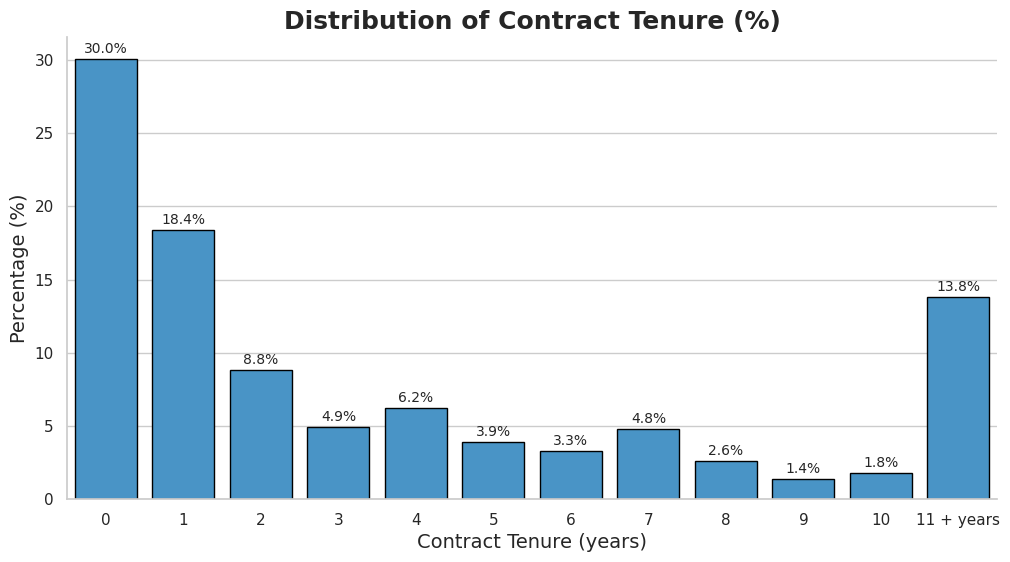

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a grouped category
df_temp = df_portefeuille.copy()

df_temp["contract_age_cat"] = df_temp["client_anciennete_contrat_annees"].apply(
    lambda x: x if x < 11 else 12   # 12 = category "≥ 11 years"
)

# 2. Convert values to strings before counting
freq_pct = (
    df_temp["contract_age_cat"]
    .replace({12: "11 + years"})
    .astype(str)
    .value_counts(normalize=True)
    .sort_index(key=lambda x: x.map(lambda v: int(v.split()[0])))  # correct sorting
    * 100
)

# 3. Plot the bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    color="#3498DB",
    edgecolor="black"
)

plt.title("Distribution of Contract Tenure (%)", fontsize=18, fontweight="bold")
plt.xlabel("Contract Tenure (years)", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# Add labels above bars
for i, value in enumerate(freq_pct.values):
    plt.text(i, value + 0.4, f"{value:.1f}%", ha="center", fontsize=10)

sns.despine()
plt.show()


Text(0, 0.5, 'Percentage (%)')

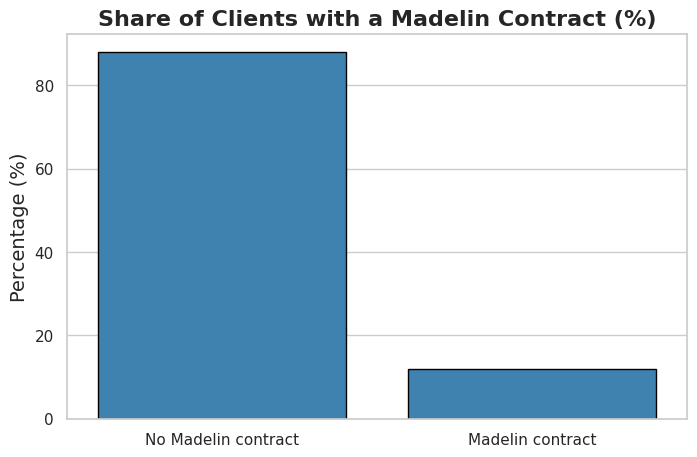

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du pourcentage
freq_pct = (
    df_portefeuille["client_est_contrat_madelin"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Nettoyage des labels (0 → No, 1 → Yes)
labels = ["No Madelin contract", "Madelin contract"]

plt.figure(figsize=(8, 5))
sns.barplot(
    x=labels,
    y=freq_pct.values,
    color="#2E86C1",
    edgecolor="black"
)

plt.title("Share of Clients with a Madelin Contract (%)", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("Percentage (%)", fontsize=14)

#


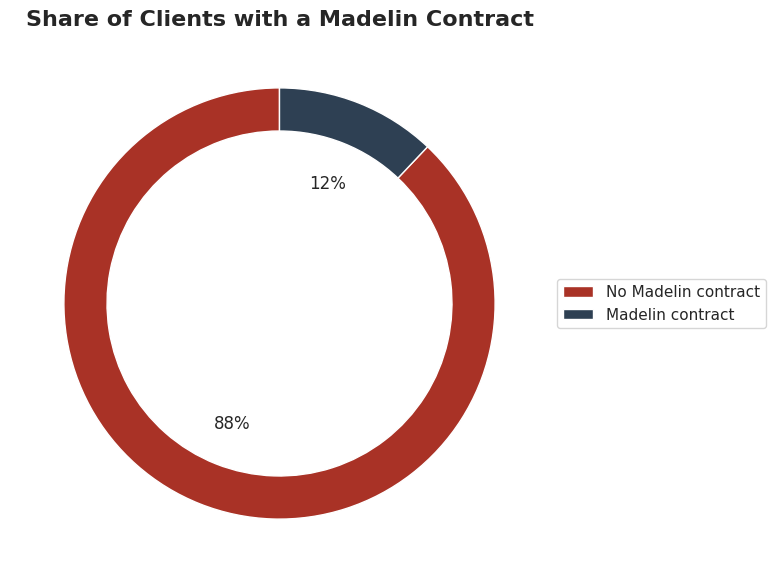

In [ ]:
import matplotlib.pyplot as plt

# Calcul des pourcentages
freq_pct = (
    df_portefeuille["client_est_contrat_madelin"]
    .value_counts(normalize=True)
    * 100
)

labels = ["No Madelin contract", "Madelin contract"]
sizes = freq_pct.sort_index().values
colors = ["#A93226", "#2E4053"]  # rouge + bleu foncé comme ton exemple

plt.figure(figsize=(7,7))

# Donut chart
plt.pie(
    sizes,
    labels=None,   # on met labels à None pour utiliser seulement les % autour
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"width": 0.20}   # <-- donut
)

# Légende sur le côté
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5))

plt.title("Share of Clients with a Madelin Contract", fontsize=16, fontweight="bold")
plt.show()


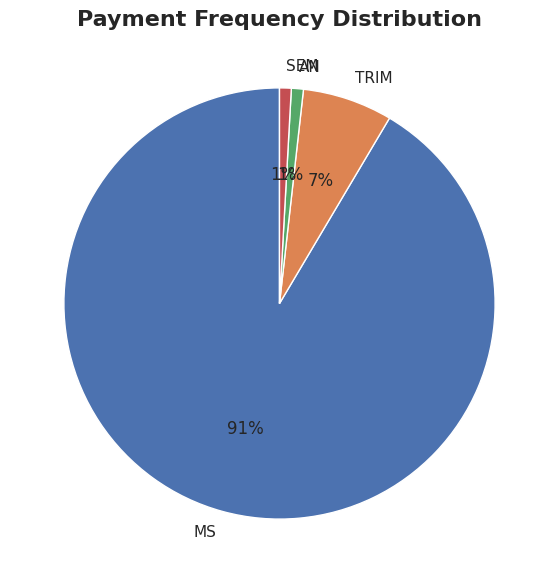

In [ ]:
import matplotlib.pyplot as plt

# 1. Calcul des pourcentages
freq_pct = (
    df_portefeuille["client_frequence_paiement"]
    .value_counts(normalize=True)
    * 100
)

labels = freq_pct.index.astype(str).tolist()
sizes  = freq_pct.values

plt.figure(figsize=(7,7))

# Pie chart classique
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.0f%%",
    startangle=90,
)

plt.title("Payment Frequency Distribution", fontsize=16, fontweight="bold")
plt.show()


In [ ]:

df_portefeuille = df_portefeuille.rename(columns={
    "client_cotisations_annualisees_n_moins2": "annual_contribution_N_minus2",
    "client_cotisations_annualisees_n_moins1": "annual_contribution_N_minus1",
    "client_cotisations_annualisees_n": "annual_contribution_N",
    "client_cotisations_annualisees_n_plus1": "annual_contribution_N_plus1"
})


vars_cot = [
    "annual_contribution_N_minus2",
    "annual_contribution_N_minus1",
    "annual_contribution_N",
    "annual_contribution_N_plus1"
]


In [ ]:
df_stats = df_portefeuille[vars_cot].agg(
    ["count", "mean",  "min", "median", "max", "sum"]
).T

df_stats


,count,mean,min,median,max,sum
annual_contribution_N_minus2,71706.0,1537.025730,138.0,1271.0,15571.0,110213967.0
annual_contribution_N_minus1,94869.0,1517.991525,141.0,1269.0,16447.0,144010338.0
annual_contribution_N,132576.0,1547.638419,138.0,1316.0,17471.0,205179711.0
annual_contribution_N_plus1,132576.0,1756.765335,138.0,1499.0,19165.0,232904921.0


In [ ]:
df_portefeuille["courtier_anciennete_annees"] = (
    df_portefeuille["courtier_anciennete_annees"]
    .fillna(0)              # si tu veux éviter les NaN → à adapter si besoin
    .astype(int)
)


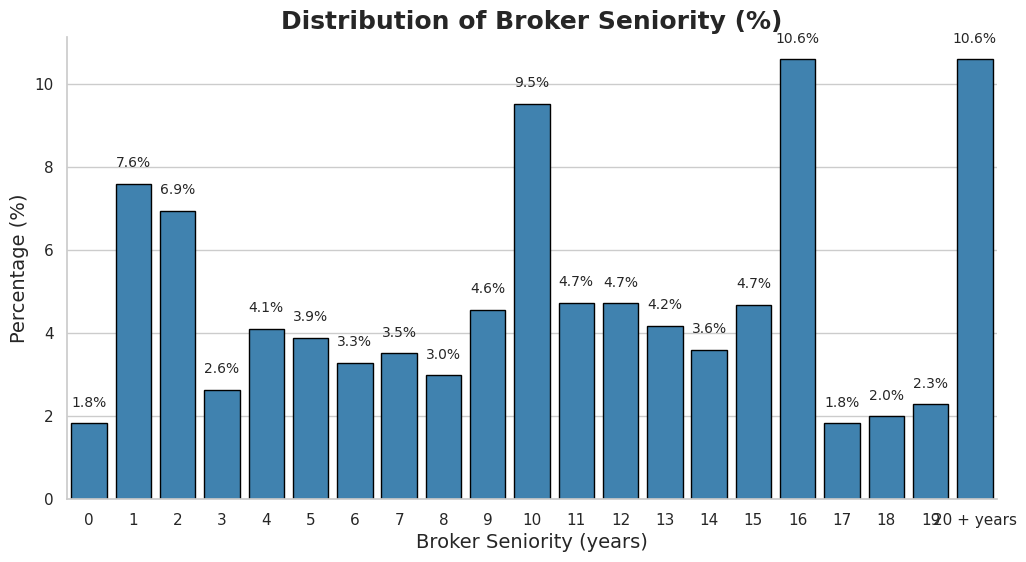

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create grouped category for broker seniority
df_temp = df_portefeuille.copy()

df_temp["broker_seniority_cat"] = df_temp["courtier_anciennete_annees"].apply(
    lambda x: x if x < 20 else 21   # 21 = category "20+ years"
)

# 2. Convert values to strings before counting
freq_pct = (
    df_temp["broker_seniority_cat"]
    .replace({21: "20 + years"})
    .astype(str)
    .value_counts(normalize=True)
    .sort_index(key=lambda x: x.map(lambda v: int(v.split()[0])))  # correct sorting
    * 100
)

# 3. Plot the bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    color="#2E86C1",
    edgecolor="black"
)

plt.title("Distribution of Broker Seniority (%)", fontsize=18, fontweight="bold")
plt.xlabel("Broker Seniority (years)", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# Add labels above bars
for i, value in enumerate(freq_pct.values):
    plt.text(i, value + 0.4, f"{value:.1f}%", ha="center", fontsize=10)

sns.despine()
plt.show()


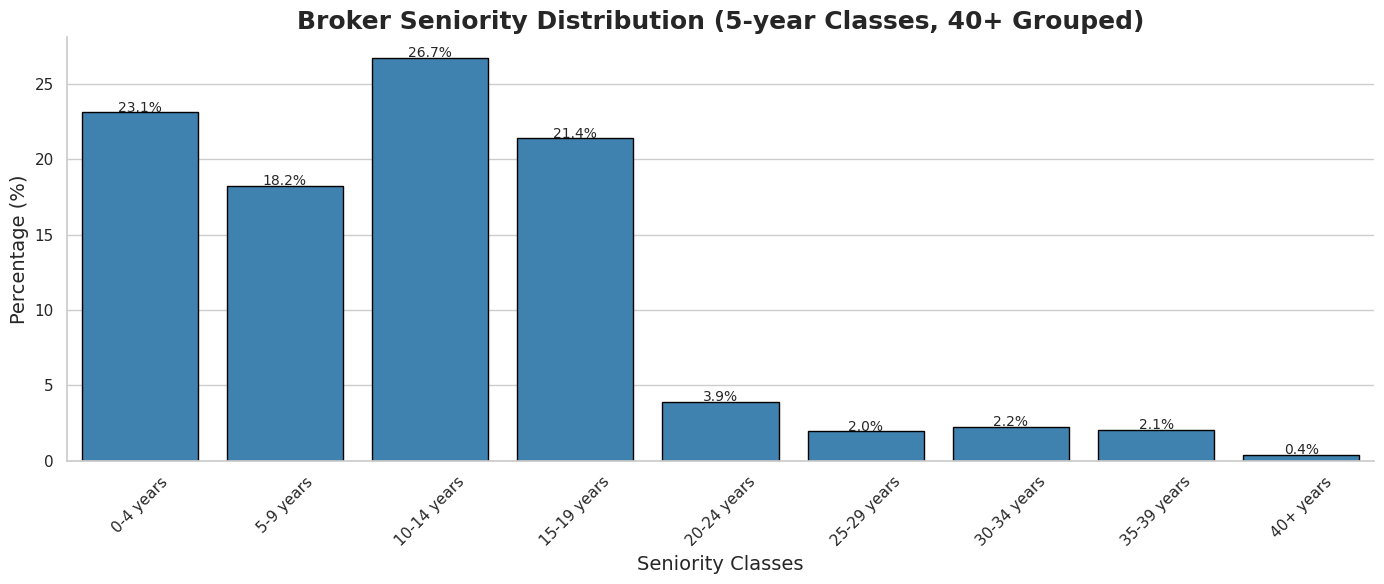

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1) Convert seniority to int
# ============================

df_portefeuille["courtier_anciennete_annees"] = (
    df_portefeuille["courtier_anciennete_annees"]
    .fillna(0)
    .astype(int)
)

# ============================
# 2) Categorize into 5-year bins with 40+
# ============================

df_temp = df_portefeuille.copy()

def categorize_seniority(x):
    if x >= 40:
        return "40+ years"
    else:
        bin_start = (x // 5) * 5
        return f"{bin_start}-{bin_start+4} years"

df_temp["broker_seniority_cat"] = df_temp["courtier_anciennete_annees"].apply(categorize_seniority)

# ============================
# 3) Percentage distribution (in REAL percentages)
# ============================

freq_pct = (
    df_temp["broker_seniority_cat"]
    .value_counts(normalize=True)
    .sort_index(key=lambda s: s.map(lambda c: 999 if c == "40+ years" else int(c.split("-")[0])))
    * 100           # <-- Conversion ici : maintenant freq_pct = vraies valeurs en %
)

# ============================
# 4) Barplot (labels well positioned)
# ============================

plt.figure(figsize=(14, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    color="#2E86C1",
    edgecolor="black"
)

plt.title("Broker Seniority Distribution (5-year Classes, 40+ Grouped)", fontsize=18, fontweight="bold")
plt.xlabel("Seniority Classes", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# CORRECTION: labels juste au-dessus des barres
for i, value in enumerate(freq_pct.values):
    plt.text(i, value + 0.05, f"{value:.1f}%", ha="center", fontsize=10)

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
df_portefeuille["courtier_code_partenaire"].nunique()

4862

In [ ]:
variables = [
    "courtier_reseau_courtage",
    "courtier_segmentation_interne",
    "courtier_type_commission",
    "courtier_est_escompte"
]

distributions = {}

for var in variables:
    print(f"\n===== Distribution of {var} =====")
    
    # Nombre
    counts = df_portefeuille[var].value_counts(dropna=False)
    print("Counts:")
    print(counts)
    
    # Pourcentages
    perc = df_portefeuille[var].value_counts(normalize=True, dropna=False) * 100
    print("\nPercentages (%):")
    print(perc.round(2))
    
    # Sauvegarde dans un dict si besoin
    distributions[var] = pd.DataFrame({
        "count": counts,
        "percentage": perc.round(2)
    })



===== Distribution of courtier_reseau_courtage =====
Counts:
courtier_reseau_courtage
COURTIER CLASSIQUE    76280
COURTIER ESCOMPTE     29586
E_COURTIER            20229
AFFAIRE DIRECTE        6481
Name: count, dtype: int64

Percentages (%):
courtier_reseau_courtage
COURTIER CLASSIQUE    57.54
COURTIER ESCOMPTE     22.32
E_COURTIER            15.26
AFFAIRE DIRECTE        4.89
Name: proportion, dtype: float64

===== Distribution of courtier_segmentation_interne =====
Counts:
courtier_segmentation_interne
VIP                   23719
VADISTE               20862
Potentiel             14630
CMA                   13860
Alptis                10460
Petit Producteur       9057
Opportuniste           8597
Filiale                6326
Potentiel Agent        6271
Groupements            5714
Sommeil                5645
Miltis                 2775
Non catégorisé         2176
Nouveau                1754
Inactif à relancer      465
Dilemme                 264
Partenariats              1
Name: count, d

In [ ]:

print(df_portefeuille["courtier_reseau_courtage"].value_counts(dropna=False))

print("\nPercentages:")
print((df_portefeuille["courtier_reseau_courtage"]
       .value_counts(normalize=True, dropna=False) * 100).round(2))


Counts:
courtier_reseau_courtage
COURTIER CLASSIQUE    76280
COURTIER ESCOMPTE     29586
E_COURTIER            20229
AFFAIRE DIRECTE        6481
Name: count, dtype: int64

Percentages:
courtier_reseau_courtage
COURTIER CLASSIQUE    57.54
COURTIER ESCOMPTE     22.32
E_COURTIER            15.26
AFFAIRE DIRECTE        4.89
Name: proportion, dtype: float64


/tmp/ipykernel_4151/3468971357.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


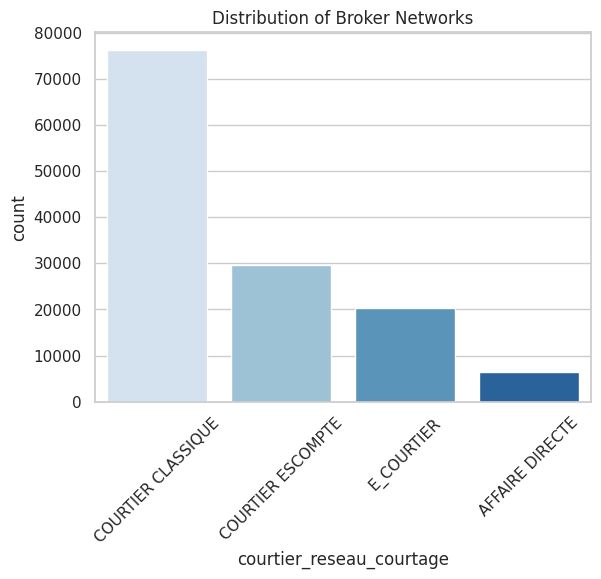

In [ ]:
sns.countplot(
    data=df_portefeuille,
    x="courtier_reseau_courtage",
    order=df_portefeuille["courtier_reseau_courtage"].value_counts().index,
    palette="Blues"
)
plt.title("Distribution of Broker Networks")
plt.xticks(rotation=45)
plt.show()


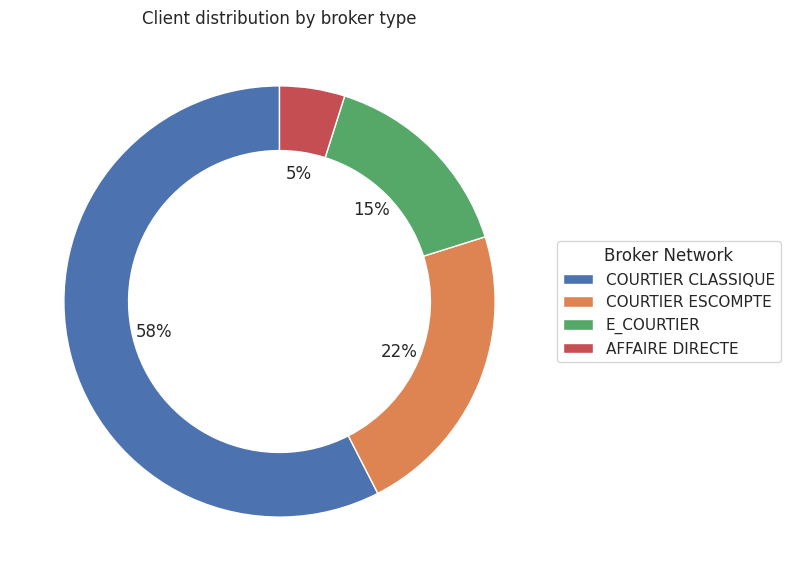

In [ ]:
import matplotlib.pyplot as plt

data = df_portefeuille["courtier_reseau_courtage"].value_counts()
labels = data.index
sizes = data.values

plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=None,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={'width':0.30},   # donut width
)

plt.legend(labels, title="Broker Network", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Client distribution by broker type")
plt.show()


/tmp/ipykernel_4151/629841213.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


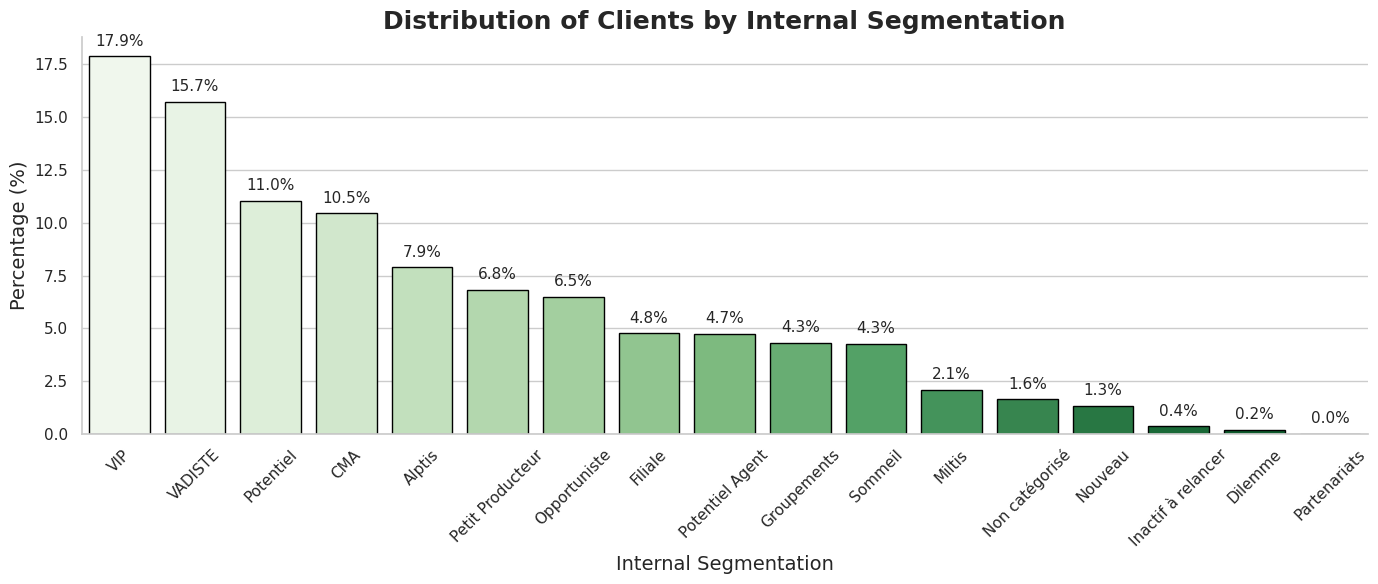

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Compute percentages
freq_pct = (
    df_portefeuille["courtier_segmentation_interne"]
    .value_counts(normalize=True) * 100
)

# 2. Sort values in descending order (optional but nicer)
freq_pct = freq_pct.sort_values(ascending=False)

# 3. Plot — large figure + modern style
plt.figure(figsize=(14, 6))   # LARGE GRAPHIC

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    palette="Greens",
    edgecolor="black"
)

plt.title("Distribution of Clients by Internal Segmentation", fontsize=18, fontweight="bold")
plt.xlabel("Internal Segmentation", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# Add % labels on bars
for i, value in enumerate(freq_pct.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center", fontsize=11)

plt.xticks(rotation=45, fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/4137450541.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


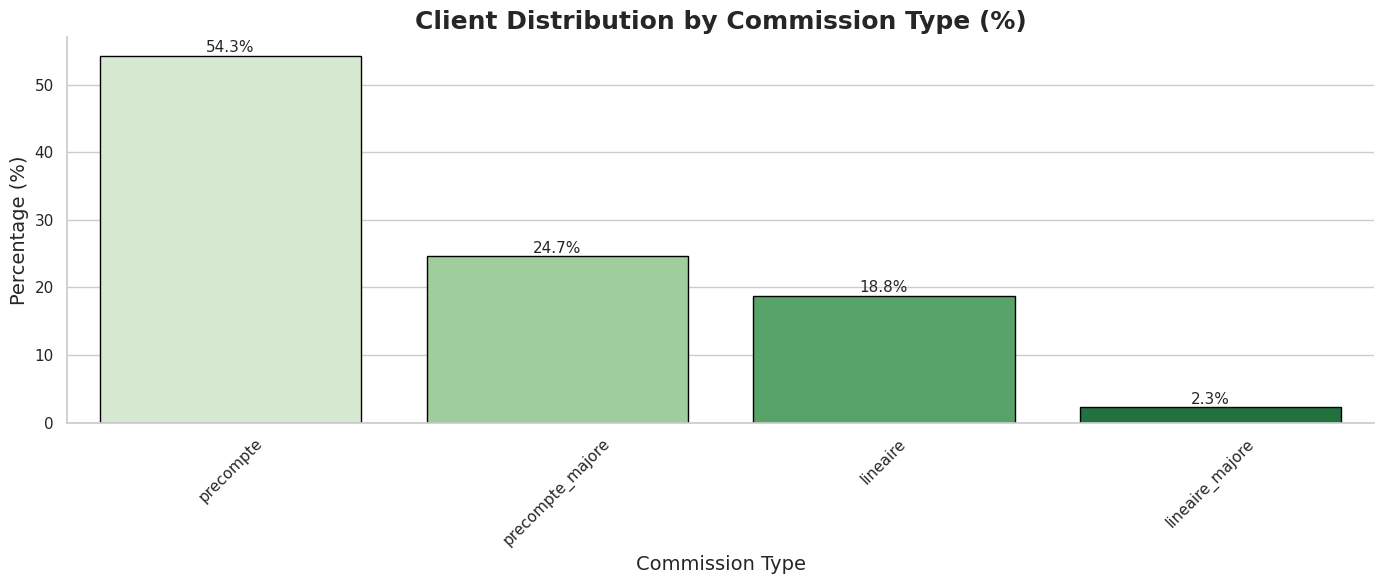

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute percentages
freq_pct = (
    df_portefeuille["courtier_type_commission"]
    .value_counts(normalize=True) * 100
)

# 2. Sort if needed (optional)
freq_pct = freq_pct.sort_values(ascending=False)

# 3. Plot — same style as segmentation interne
plt.figure(figsize=(14, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    palette="Greens",     # SAME COLORS as segmentation
    edgecolor="black"
)

plt.title("Client Distribution by Commission Type (%)", fontsize=18, fontweight="bold")
plt.xlabel("Commission Type", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# Add % labels above bars
for i, value in enumerate(freq_pct.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center", fontsize=11)

plt.xticks(rotation=45, fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
df_brokers = df_portefeuille.drop_duplicates(subset="courtier_code_partenaire")


In [ ]:
counts = df_brokers["courtier_reseau_courtage"].value_counts()
perc = df_brokers["courtier_reseau_courtage"].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages (%):\n", perc.round(2))


Counts:
 courtier_reseau_courtage
COURTIER CLASSIQUE    4533
COURTIER ESCOMPTE      288
E_COURTIER              40
AFFAIRE DIRECTE          1
Name: count, dtype: int64

Percentages (%):
 courtier_reseau_courtage
COURTIER CLASSIQUE    93.23
COURTIER ESCOMPTE      5.92
E_COURTIER             0.82
AFFAIRE DIRECTE        0.02
Name: proportion, dtype: float64


/tmp/ipykernel_4151/4214678958.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


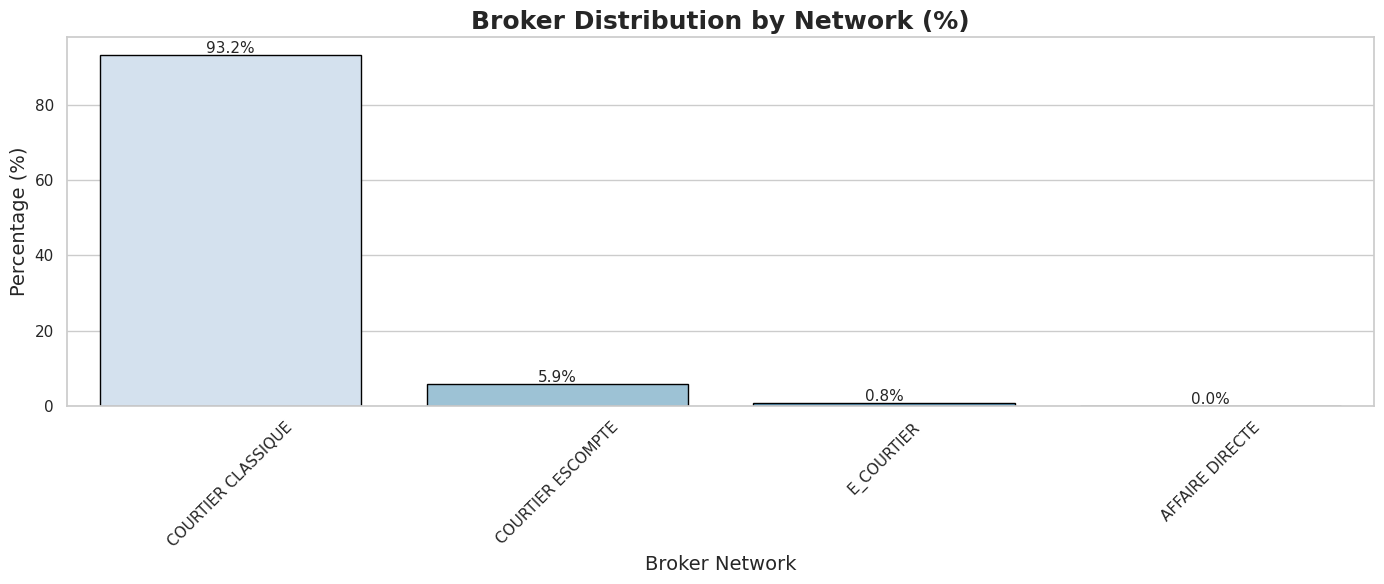

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

freq_pct = (
    df_brokers["courtier_reseau_courtage"]
    .value_counts(normalize=True) * 100
)

freq_pct = freq_pct.sort_values(ascending=False)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    palette="Blues",
    edgecolor="black"
)

plt.title("Broker Distribution by Network (%)", fontsize=18, fontweight="bold")
plt.xlabel("Broker Network", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

for i, v in enumerate(freq_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/685061402.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


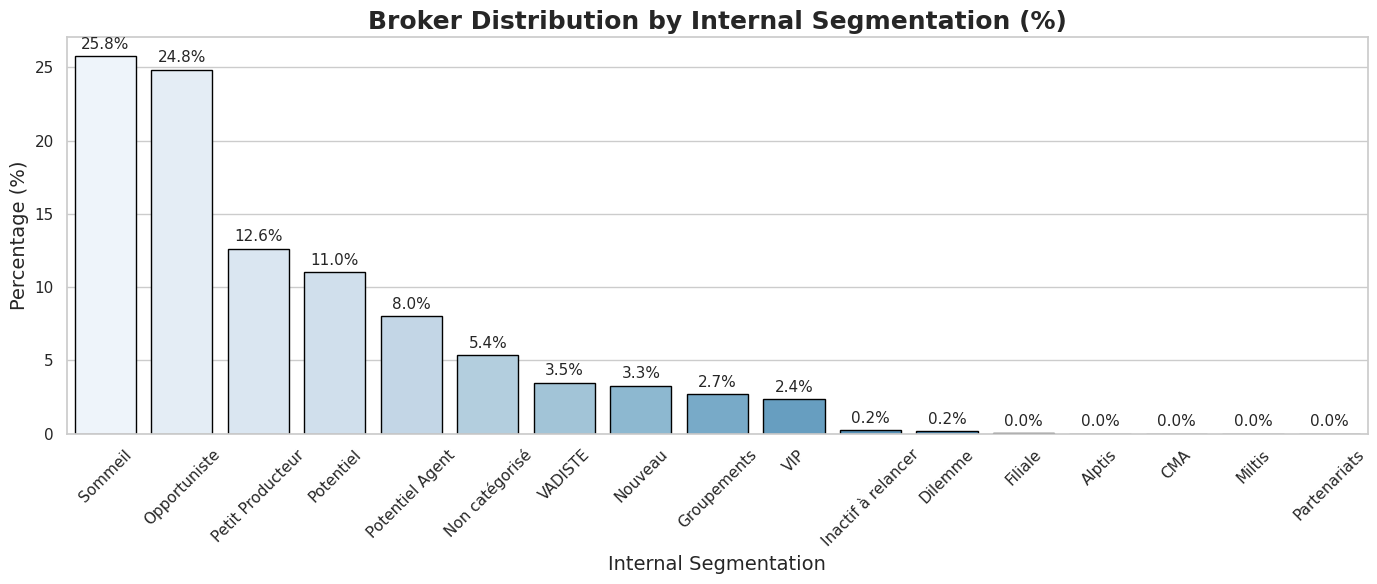

In [ ]:
freq_pct = (
    df_brokers["courtier_segmentation_interne"]
    .value_counts(normalize=True) * 100
)

freq_pct = freq_pct.sort_values(ascending=False)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    palette="Blues",
    edgecolor="black"
)

plt.title("Broker Distribution by Internal Segmentation (%)", fontsize=18, fontweight="bold")
plt.xlabel("Internal Segmentation", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

for i, v in enumerate(freq_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/3138758847.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


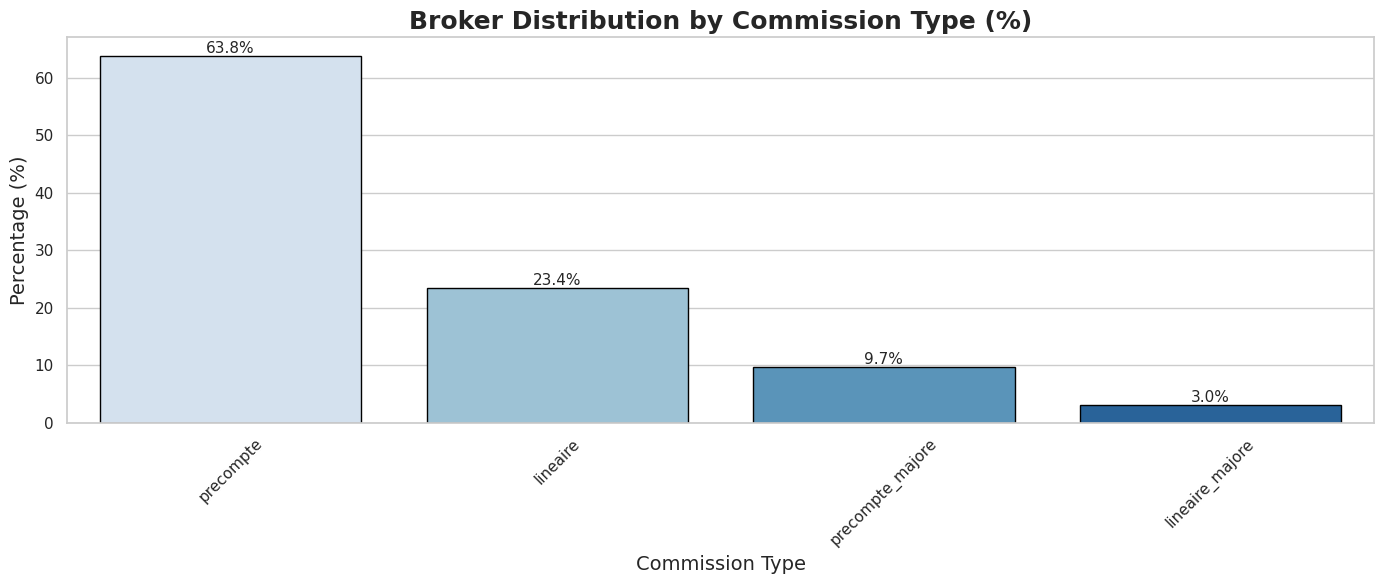

In [ ]:
freq_pct = (
    df_brokers["courtier_type_commission"]
    .value_counts(normalize=True) * 100
)

freq_pct = freq_pct.sort_values(ascending=False)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=freq_pct.index,
    y=freq_pct.values,
    palette="Blues",
    edgecolor="black"
)

plt.title("Broker Distribution by Commission Type (%)", fontsize=18, fontweight="bold")
plt.xlabel("Commission Type", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

for i, v in enumerate(freq_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Analysons la fréquence des interaction des clients 
freq_interactions = df_interactions.groupby('client_code').size()
freq_interactions.describe()

count    65895.000000
mean         3.821125
std          4.499766
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        224.000000
dtype: float64

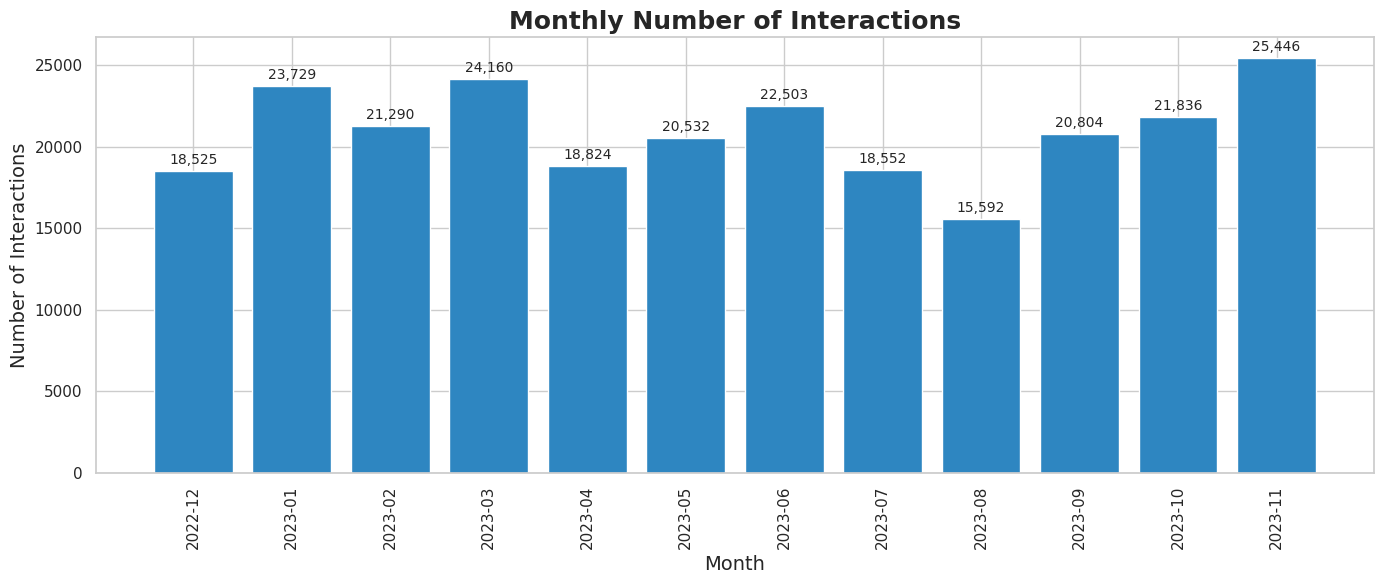

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convertir la date en datetime
df_interactions["interaction_date"] = pd.to_datetime(df_interactions["interaction_date"])

# 2. Comptage des interactions par mois
freq_par_mois = (
    df_interactions
    .groupby(df_interactions["interaction_date"].dt.to_period("M"))
    .size()
)

# 3. Convertir index en string (pour affichage propre)
freq_par_mois.index = freq_par_mois.index.astype(str)

# 4. Plot propre
plt.figure(figsize=(14, 6))
bars = plt.bar(freq_par_mois.index, freq_par_mois.values, color="#2E86C1")

plt.title("Monthly Number of Interactions", fontsize=18, fontweight="bold")
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Interactions", fontsize=14)

# 5. Ajouter étiquettes sur chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(freq_par_mois.values)*0.01,   # légère marge
        f"{int(height):,}",                       # format 12,345
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# Compter les interactions par mois
freq_par_mois = (
    df_interactions
    .groupby(df_interactions["interaction_date"].dt.to_period("M"))
    .size()
)

# Moyenne mensuelle
monthly_average = freq_par_mois.mean()
monthly_average


np.float64(20982.75)

In [ ]:
df_interactions['interaction_motif'].value_counts(normalize=True) * 100

interaction_motif
Frais courants                                  15.200979
Dentaire                                        11.937584
Hospitalisation                                 10.437145
Télétransmission                                 7.670189
Médecine douce                                   7.560576
Tiers payant                                     7.185664
Optique                                          6.641567
Données administratives                          3.891689
Adhésion                                         3.859917
Modalités de règlement                           3.230034
Demande de documents                             3.139086
Résiliation                                      2.954808
Montant des cotisations                          2.684745
Demandes générales                               2.330486
Audioprothèse                                    2.096166
Cures thermales                                  1.659697
Modification de garantie                         1.647

/tmp/ipykernel_4151/3132409835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


AttributeError: Rectangle.set() got an unexpected keyword argument 'colors'

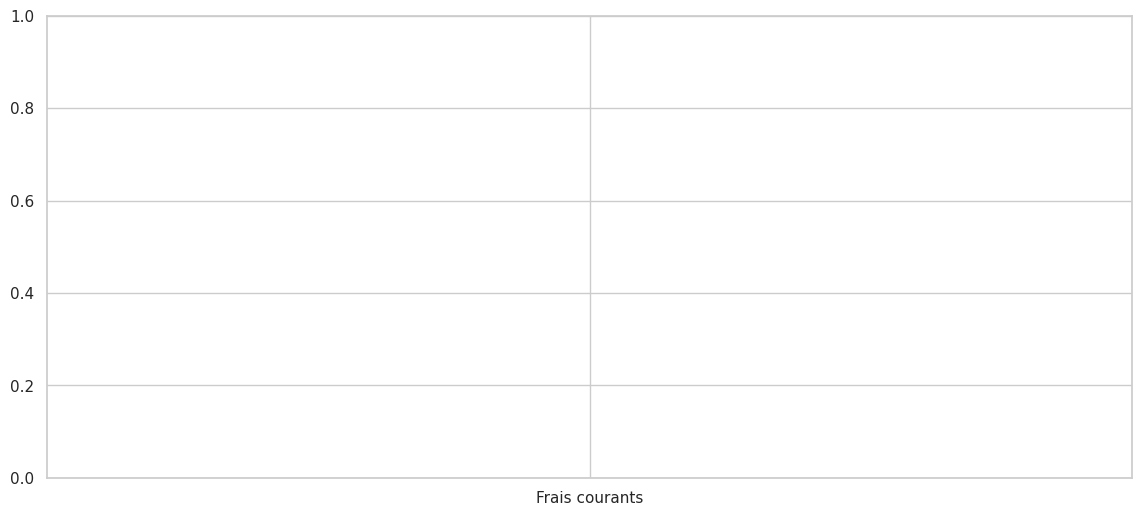

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculer les pourcentages
motifs_pct = (
    df_interactions['interaction_motif']
    .value_counts(normalize=True) * 100
)

# 2. Garder uniquement les 7 premiers
motifs_top7 = motifs_pct.head(7)

# 3. Palette bleu dégradé
palette = sns.color_palette("Blues", n_colors=7)

# 4. Plot
plt.figure(figsize=(14, 6))
sns.barplot(
    x=motifs_top7.index,
    y=motifs_top7.values,
    colors=colors,
    palette=palette,
    edgecolor="black"
)

plt.title("Top 7 Interaction Reasons (%)", fontsize=18, fontweight="bold")
plt.xlabel("Interaction Reason", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# 5. Ajout des labels %
for i, v in enumerate(motifs_top7.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.tight_layout()
plt.show()


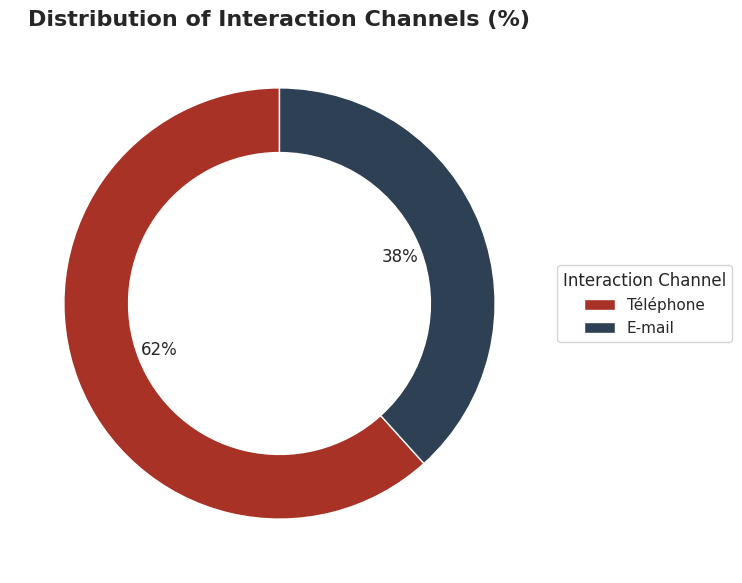

In [ ]:
import matplotlib.pyplot as plt

# 1. Distribution
canal_counts = df_interactions['interaction_canal'].value_counts()
labels = canal_counts.index
sizes = canal_counts.values

# 2. Palette de 2 couleurs
colors = ["#A93226", "#2E4053"]  

plt.figure(figsize=(7,7))

# 3. Donut chart
plt.pie(
    sizes,
    labels=None,
    autopct="%1.0f%%",
    startangle=90,
    colors=colors[:len(sizes)],     # applique tes couleurs
    wedgeprops={"width": 0.30}      # donut thickness
)

# 4. Légende
plt.legend(
    labels,
    title="Interaction Channel",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Distribution of Interaction Channels (%)", fontsize=16, fontweight="bold")
plt.show()


In [ ]:
freq_impayes = df_impayes.groupby('client_code').size()
freq_impayes.describe()

count    7167.000000
mean        2.174829
std         1.768721
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        14.000000
dtype: float64

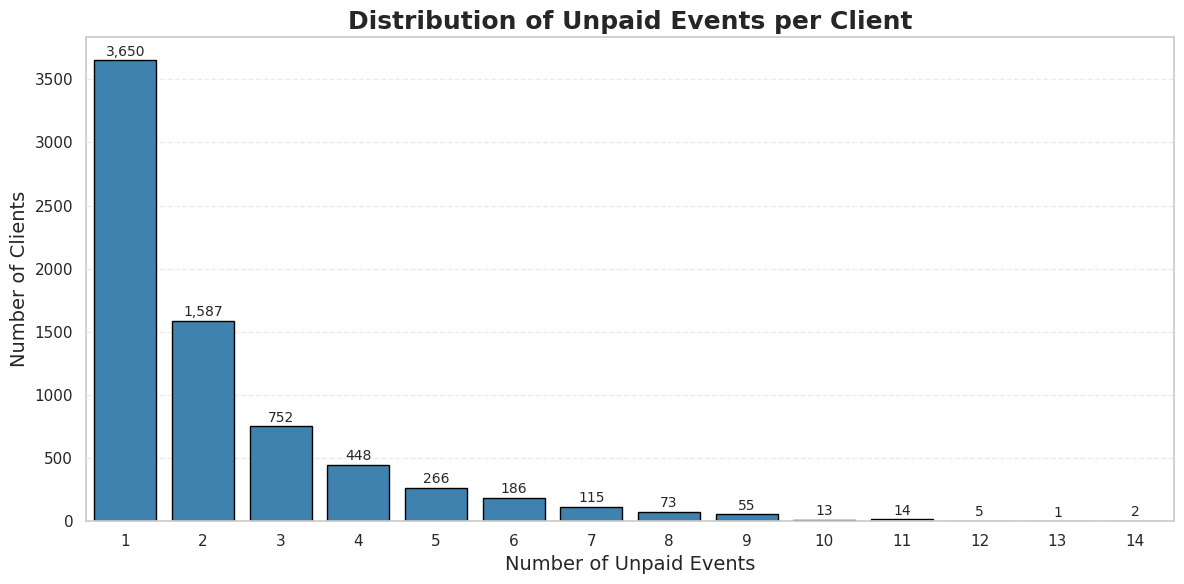

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comptage du nombre de clients par nombre d'impayés
freq_counts = freq_impayes.value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=freq_counts.index,
    y=freq_counts.values,
    color="#2E86C1",
    edgecolor="black"
)

plt.title("Distribution of Unpaid Events per Client", fontsize=18, fontweight="bold")
plt.xlabel("Number of Unpaid Events", fontsize=14)
plt.ylabel("Number of Clients", fontsize=14)

# Ajouter les labels (valeurs) sur les barres
for i, v in enumerate(freq_counts.values):
    plt.text(i, v + max(freq_counts.values)*0.01, f"{v:,}", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


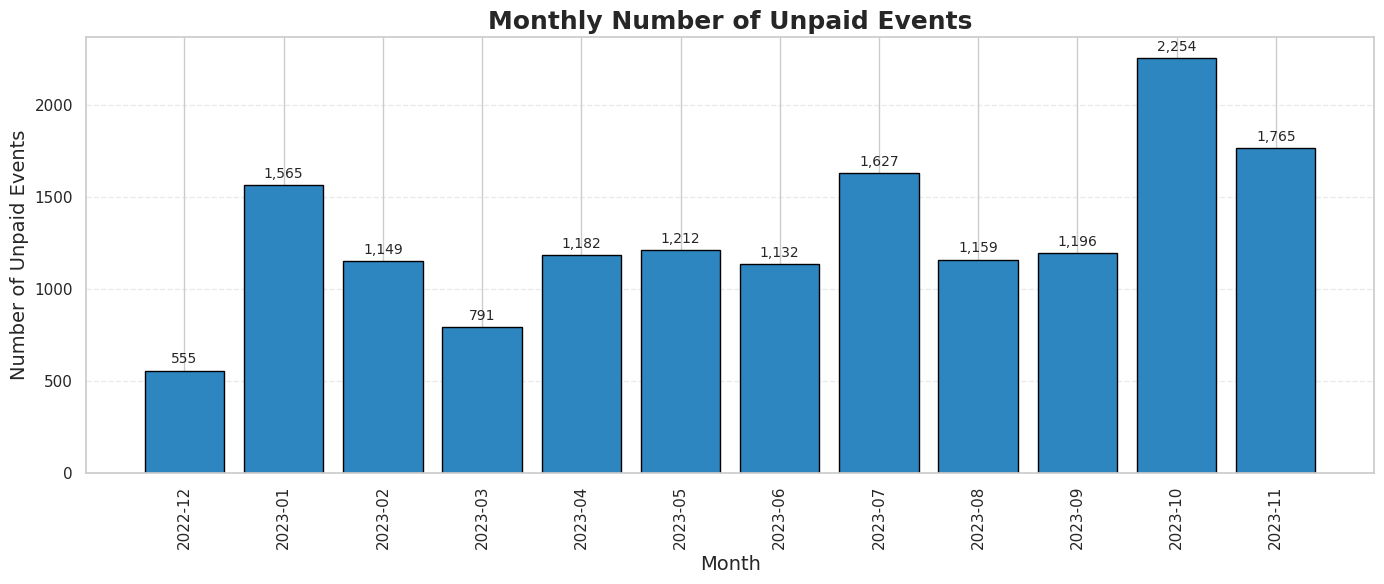

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertir la date en datetime
df_impayes['impaye_date_debut_action'] = pd.to_datetime(df_impayes['impaye_date_debut_action'])

# 2. Nombre d'impayés par mois
freq_par_mois = (
    df_impayes
    .groupby(df_impayes['impaye_date_debut_action'].dt.to_period('M'))
    .size()
)

# 3. Transformer index en string propre pour l'affichage
freq_par_mois.index = freq_par_mois.index.astype(str)

# 4. Plot propre
plt.figure(figsize=(14, 6))
bars = plt.bar(freq_par_mois.index, freq_par_mois.values, color="#2E86C1", edgecolor="black")

plt.title("Monthly Number of Unpaid Events", fontsize=18, fontweight="bold")
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Unpaid Events", fontsize=14)

# 5. Labels au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(freq_par_mois.values) * 0.01,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
freq_par_mois.mean()


np.float64(1298.9166666666667)

In [ ]:
df_impayes['impaye_type_action'].value_counts(normalize=True) * 100

impaye_type_action
1er Impayé                 43.876307
1ere lettre de relance     22.005517
Mise en demeure            19.355873
2ème Impayé                 7.538333
Suspension de garanties     3.971258
Annonce du contentieux      2.617566
En recouvrement             0.635145
Name: proportion, dtype: float64

/tmp/ipykernel_4151/1750921044.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


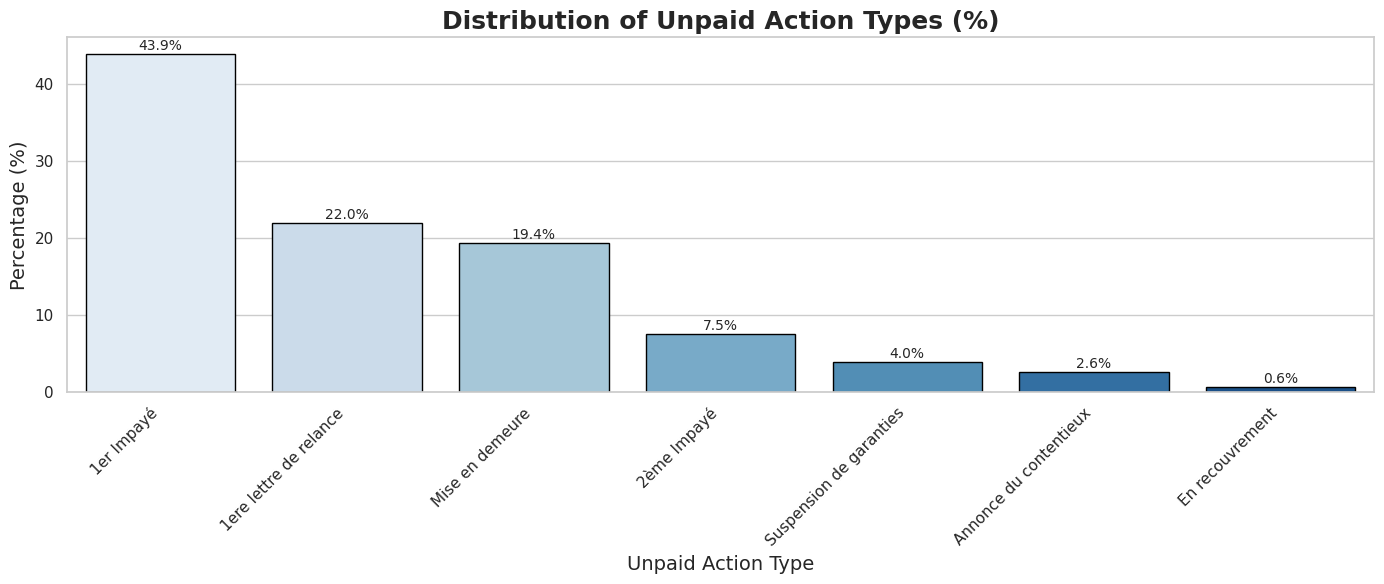

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculer les pourcentages
type_pct = (
    df_impayes['impaye_type_action']
    .value_counts(normalize=True) * 100
).sort_values(ascending=False)

# 2. Palette bleu dégradé (propre)
palette = sns.color_palette("Blues", n_colors=len(type_pct))

# 3. Bar chart
plt.figure(figsize=(14, 6))

sns.barplot(
    x=type_pct.index,
    y=type_pct.values,
    palette=palette,
    edgecolor="black"
)

plt.title("Distribution of Unpaid Action Types (%)", fontsize=18, fontweight="bold")
plt.xlabel("Unpaid Action Type", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

# 4. Ajouter les labels %
for i, v in enumerate(type_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/3559682291.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


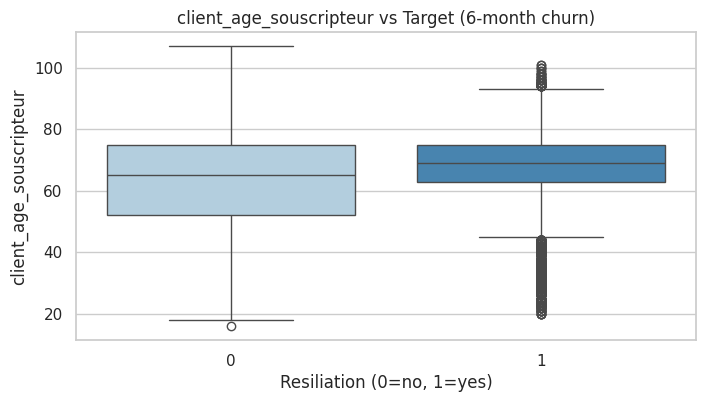

/tmp/ipykernel_4151/3559682291.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


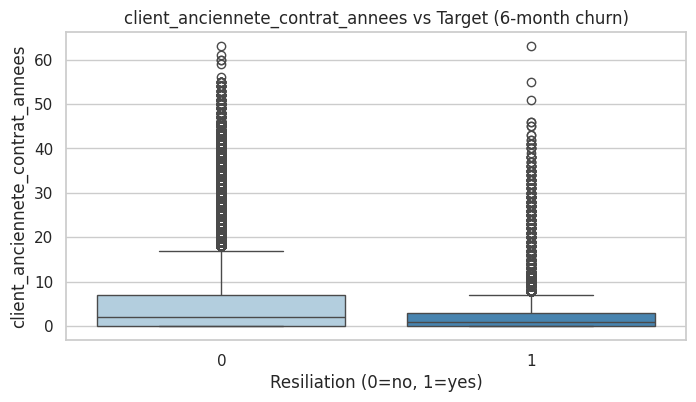

KeyError: 'client_cotisations_annualisees_n'

<Figure size 800x400 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'client_age_souscripteur',
    'client_anciennete_contrat_annees',
    'client_cotisations_annualisees_n',
    'courtier_anciennete_annees',
    'courtier_nb_affaires_n_moins1',
    'courtier_nb_radiations_n_moins1'
]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(
        x=df_portefeuille['target_resiliation_6mois'],
        y=df_portefeuille[col],
        palette='Blues'
    )
    plt.title(f"{col} vs Target (6-month churn)")
    plt.xlabel("Resiliation (0=no, 1=yes)")
    plt.show()


/tmp/ipykernel_4151/2825674293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


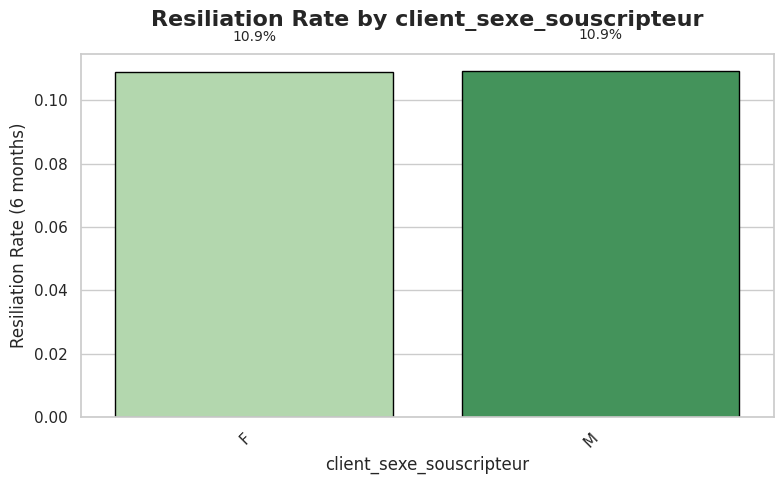

/tmp/ipykernel_4151/2825674293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


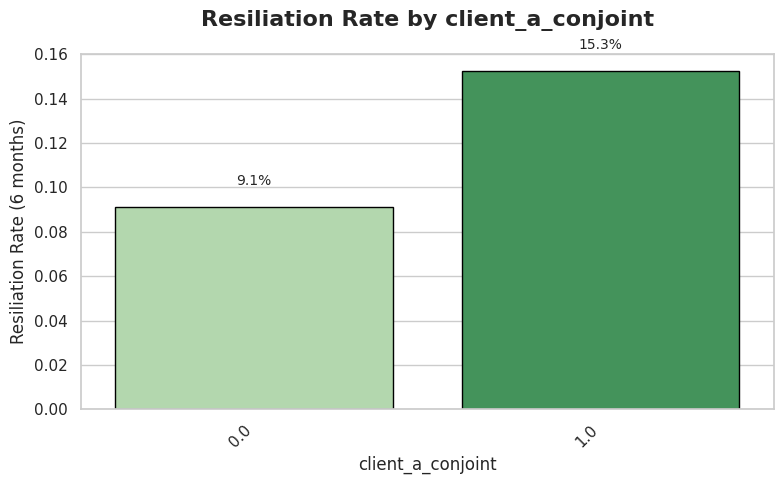

/tmp/ipykernel_4151/2825674293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


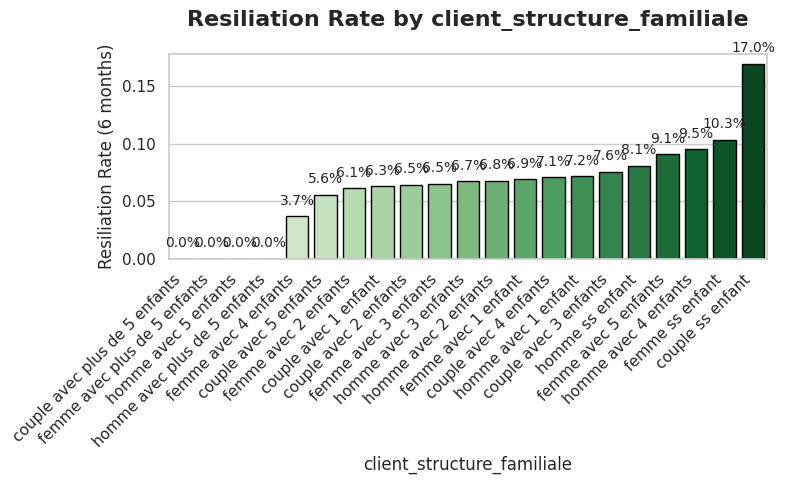

In [ ]:
cat_cols = [
    "client_sexe_souscripteur",
    "client_a_conjoint",
    "client_structure_familiale"
]

for col in cat_cols:
    rate = (
        df_portefeuille
        .groupby(col)["target_resiliation_6mois"]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(8, 5))  # 🔥 plus haut qu'avant
    ax = sns.barplot(
        x=rate.index,
        y=rate.values,
        palette="Greens",
        edgecolor="black"
    )

    plt.title(f"Resiliation Rate by {col}", fontsize=16, fontweight="bold", pad=20)
    # 🔥 pad=20 = espace supplémentaire entre le titre et le graphique

    plt.ylabel("Resiliation Rate (6 months)")
    plt.xticks(rotation=45, ha="right")

    # --- Ajout des étiquettes ---
    for i, v in enumerate(rate.values):
        ax.text(
            i,
            v + 0.01,       # 🔥 marge augmentée pour l'esthétique
            f"{v*100:.1f}%",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_4151/1282595990.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_class")["target_resiliation_6mois"]
/tmp/ipykernel_4151/1282595990.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


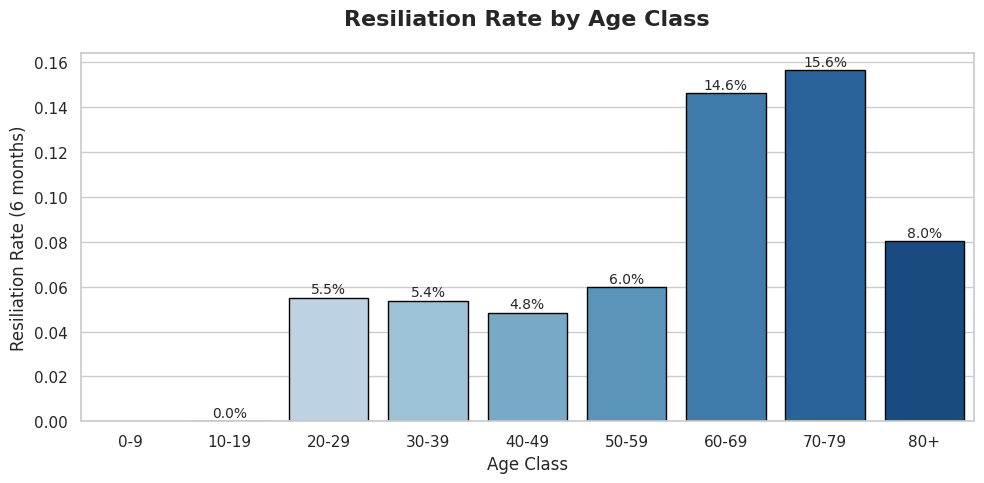

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Définition des classes d'âge
bins = list(range(0, 81, 10)) + [150]  # 0-9, 10-19, ..., 70-79, 80+
labels = [f"{i}-{i+9}" for i in range(0, 80, 10)] + ["80+"]

df_portefeuille["age_class"] = pd.cut(
    df_portefeuille["client_age_souscripteur"],
    bins=bins,
    labels=labels,
    right=False
)

# 2. Calcul du taux de résiliation par classe d'âge
age_resil_rate = (
    df_portefeuille
    .groupby("age_class")["target_resiliation_6mois"]
    .mean()
)

# 3. Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=age_resil_rate.index,
    y=age_resil_rate.values,
    palette="Blues",
    edgecolor="black"
)

plt.title("Resiliation Rate by Age Class", fontsize=16, fontweight="bold", pad=20)
plt.ylabel("Resiliation Rate (6 months)")
plt.xlabel("Age Class")

# 4. Ajout des étiquettes (%)
for i, v in enumerate(age_resil_rate.values):
    ax.text(
        i,
        v + 0.002,
        f"{v*100:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/1528526602.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


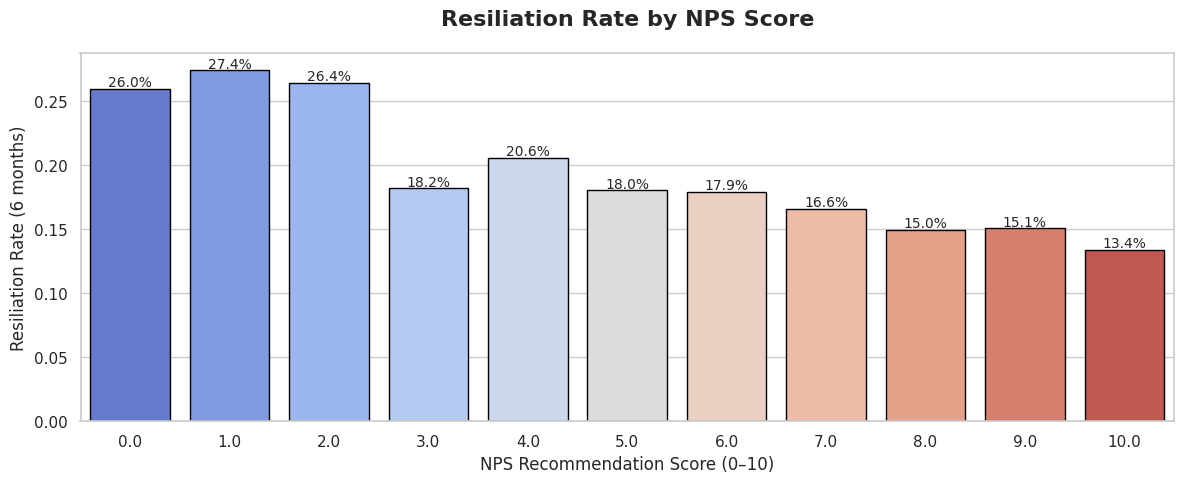

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul du taux de résiliation par note NPS
nps_resil = (
    df_portefeuille
    .groupby("client_nps_note_reco_n")["target_resiliation_6mois"]
    .mean()
    .sort_index()
)

# 2. Plot
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    x=nps_resil.index,
    y=nps_resil.values,
    palette="coolwarm",
    edgecolor="black"
)

plt.title("Resiliation Rate by NPS Score", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("NPS Recommendation Score (0–10)", fontsize=12)
plt.ylabel("Resiliation Rate (6 months)", fontsize=12)

# 3. Ajout des étiquettes (%)
for i, v in enumerate(nps_resil.values):
    ax.text(
        i,
        v + 0.002,
        f"{v*100:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/2944367898.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


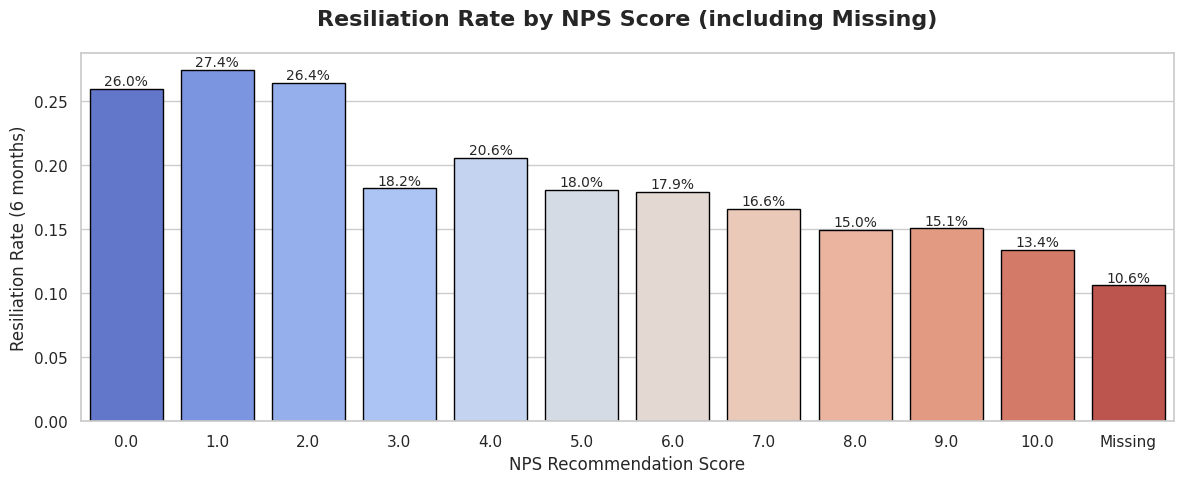

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Créer une copie avec NaN remplacés par "Missing"
df_temp = df_portefeuille.copy()
df_temp["client_nps_note_reco_n"] = df_temp["client_nps_note_reco_n"].fillna("Missing")

# 2. Calcul du taux de résiliation par note NPS (0-10 + Missing)
nps_resil = (
    df_temp
    .groupby("client_nps_note_reco_n")["target_resiliation_6mois"]
    .mean()
)

# 3. Trier correctement : Missing à la fin
sorted_index = sorted(
    [x for x in nps_resil.index if x != "Missing"],
    key=lambda x: int(x)
) + ["Missing"]

nps_resil = nps_resil.loc[sorted_index]

# 4. Plot
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    x=nps_resil.index,
    y=nps_resil.values,
    palette="coolwarm",
    edgecolor="black"
)

plt.title("Resiliation Rate by NPS Score (including Missing)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("NPS Recommendation Score", fontsize=12)
plt.ylabel("Resiliation Rate (6 months)", fontsize=12)

# 5. Ajouter les labels %
for i, v in enumerate(nps_resil.values):
    ax.text(
        i,
        v + 0.003,
        f"{v*100:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [ ]:
#Ici se trouvent les fonctions d'agrégation des fichiers secondaires ainsi de merge générale des table
#  (impayés, réclamations, interaction, consommations)
#Pour voir l'explication détaillée des démarches employées, se réferer au notebook de chaque fichier

import pandas as pd


def aggregate_reclamations(df_reclamations):
    """
    Agrège les réclamations par client_code avec création d’indicateurs
    (motifs, canaux, sensibilité, initiateur, délais…) selon la méthode présentée dans
    le notebook "reclamation_aggregation.ipynb"

    Arg: 
    df_reclamations: DataFrame, contient le fichier des réclamations non aggrégé

    Returns: 
    df_agg: DataFrame, fichier des réclamations aggrégé
    """

    # ============================================================
    # ÉTAPE 1 — Nombre total de réclamations par client
    # ============================================================
    df_agg = (
        df_reclamations
        .groupby("client_code")
        .agg(recla_nombre=("client_code", "count"))
        .reset_index()
    )

    # ============================================================
    # ÉTAPE 2 — Colonnes sur motifs principaux & canaux principal/secondaire
    # ============================================================

    #One hot encoding of motif columns, and creation of recla_motif_Autre for non top5 motif
    df_reclamations=pd.get_dummies(df_reclamations, columns=["recla_motif"], dtype=int) 
    colonnes_motif = [c for c in df_reclamations.columns if (c.startswith("recla_motif_")) & (c not in ["recla_motif_acpr","recla_motif_sensibilite"])]
    top5 = df_reclamations[colonnes_motif].sum().sort_values(ascending=False).head(5).index.tolist()
    autres = list(set(colonnes_motif) - set(top5))
    df_reclamations["recla_motif_Autre"] = df_reclamations[autres].sum(axis=1)
    colonnes_motif =  top5 + ["recla_motif_Autre","client_code"]
    df_motifs = df_reclamations.groupby("client_code")[top5 + ["recla_motif_Autre"]].sum().reset_index()

    # Canal principal (mode)
    canal_principal = (
        df_reclamations
        .groupby("client_code")["recla_canal_entrant"]
        .agg(lambda x: x.value_counts().idxmax())
        .rename("recla_canal_entrant_principale")
    )

    # Canal secondaire (2e mode)
    def second_mode(x):
        counts = x.value_counts()
        return counts.index[1] if len(counts) > 1 else None

    canal_secondaire = (
        df_reclamations
        .groupby("client_code")["recla_canal_entrant"]
        .agg(second_mode)
        .rename("recla_canal_entrant_secondaire")
    )

    # Fusion des résultats étape 2
    df_agg = (
        df_agg
        .merge(df_motifs, on="client_code", how="left")
        .merge(canal_principal, on="client_code", how="left")
        .merge(canal_secondaire, on="client_code", how="left")
    )

    # ============================================================
    # ÉTAPE 3 — Réclamations sensibles
    # ============================================================
    motif_resiliation = ["Menace de résiliation"]
    motif_tiers = ["Menace saisie d'un tiers"]
    motif_courtier = ["Défaut du courtier"]
    motif_autre = [
        'Sur-réclamation - Maintien de contestation',
        'Réclamation médiatisée',
        'Médiation',
        'Complexe et/ou multi canal',
        'Réclamation par un tiers'
    ]

    df_reclamations["recla_sensible_resiliation"] = df_reclamations["recla_motif_sensibilite"].isin(motif_resiliation).astype(int)
    df_reclamations["recla_sensible_tiers"] = df_reclamations["recla_motif_sensibilite"].isin(motif_tiers).astype(int)
    df_reclamations["recla_sensible_courtier"] = df_reclamations["recla_motif_sensibilite"].isin(motif_courtier).astype(int)
    df_reclamations["recla_sensible_autre"] = df_reclamations["recla_motif_sensibilite"].isin(motif_autre).astype(int)

    df_sensible_agg = df_reclamations.groupby("client_code").agg(
        recla_sensible_resiliation=("recla_sensible_resiliation", "sum"),
        recla_sensible_tiers=("recla_sensible_tiers", "sum"),
        recla_sensible_courtier=("recla_sensible_courtier", "sum"),
        recla_sensible_autre=("recla_sensible_autre", "sum"),
    ).reset_index()

    df_agg = df_agg.merge(df_sensible_agg, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 4 — Nombre de réclamations initiées par le client / adhérent
    # ============================================================
    df_reclamations["recla_initiateur_client"] = df_reclamations["recla_initiateur"].isin(
        ['Client', 'Adhérent / Participant']
    ).astype(int)

    df_initiateur = (
        df_reclamations
        .groupby("client_code")["recla_initiateur_client"]
        .sum()
        .reset_index()
    )

    df_agg = df_agg.merge(df_initiateur, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 5 — Réclamations non clôturées
    # ============================================================
    df_reclamations["recla_non_cloturee"] = (
        (df_reclamations["recla_reponse_gestion"] == "Non") |
        (df_reclamations["recla_solution_trouvee"] == "Négative")
    ).astype(int)

    df_non_cloture = (
        df_reclamations
        .groupby("client_code")["recla_non_cloturee"]
        .sum()
        .reset_index()
    )

    df_agg = df_agg.merge(df_non_cloture, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 6 — Liste des dates de réception
    # ============================================================
    df_dates = df_reclamations.groupby("client_code").agg(
        recla_date_reception=("recla_date_reception", list)
    ).reset_index()

    df_agg = df_agg.merge(df_dates, on="client_code", how="left")

    # ============================================================
    # ÉTAPE 7 — Délais court / moyen / long
    # ============================================================
    df_reclamations["recla_date_cloture"] = pd.to_datetime(df_reclamations["recla_date_cloture"])
    df_reclamations["recla_date_reception"] = pd.to_datetime(df_reclamations["recla_date_reception"])

    df_reclamations["recla_delais"] = df_reclamations["recla_date_cloture"] - df_reclamations["recla_date_reception"]
    df_reclamations["recla_delais_jours"] = df_reclamations["recla_delais"].dt.days

    df_reclamations["recla_delais_court"] = (df_reclamations["recla_delais_jours"] <= 3).astype(int)
    df_reclamations["recla_delais_moyen"] = (
        (df_reclamations["recla_delais_jours"] > 3) &
        (df_reclamations["recla_delais_jours"] <= 15)
    ).astype(int)
    df_reclamations["recla_delais_long"] = (df_reclamations["recla_delais_jours"] > 15).astype(int)

    df_delais_agg = df_reclamations.groupby("client_code").agg(
        recla_delais_court=("recla_delais_court", "sum"),
        recla_delais_moyen=("recla_delais_moyen", "sum"),
        recla_delais_long=("recla_delais_long", "sum")
    ).reset_index()

    df_agg = df_agg.merge(df_delais_agg, on="client_code", how="left")

    # ============================================================
    # FIN — Retour du dataframe agrégé final
    # ============================================================
    return df_agg



def aggregate_consommations(df_consommations):
    """
    Agrège les consommations par client et construit une structure
    d'informations détaillées par date (annee_mois_paiement).

    Méthode d'agrégation :
    - Agrégation par somme pour toutes les colonnes sauf annee_mois_paiement
    - Agrégation en faisant une liste de date pour la colonne annee_mois_paiement
    - Création de la colonne info_par_annee_mois_paiement
        construction d'un dictionnaire imbriqué : date → soin → montants

    Arg: 
    df_consommations: DataFrame, contient le fichier des consommations non aggrégé

    Returns: 
    df_agg: DataFrame, fichier des consommations aggrégé
    """

    # --- Step 1 : Nettoyer la colonne date ---
    df = df_consommations.copy()
    df["annee_mois_paiement"] = df["annee_mois_paiement"].astype("string").str.strip()

    # --- Step 2 : Colonnes numériques à sommer ---
    cols_num = df.select_dtypes(include=["float64"]).columns.tolist()

    # --- Step 3 : Agrégation principale (sommes + dates uniques) ---
    df_agg = (
        df.groupby("client_code")
          .agg(
              {**{col: "sum" for col in cols_num},
               "annee_mois_paiement": lambda x: sorted(x.dropna().unique().tolist())}
          )
          .reset_index()
    )

    # --- Step 4 : Mapping des colonnes de soins ---
    soins = ["hospitalisation", "soins_medicaux", "pharmacie", "optique", "dentaire", "divers"]
    mapping_soins = {
        soin: {
            "frais_reels": f"frais_reels_{soin}",
            "reste_a_charge": f"reste_a_charge_{soin}",
            "remb_alptis": f"remb_alptis_{soin}",
            "remb_ro": f"remb_ro_{soin}",
        }
        for soin in soins
    }

    # --- Step 5 : Fonction pour construire le dict par date ---
    def build_info_dict(df_client):
        info = {}
        for _, row in df_client.iterrows():
            date = row["annee_mois_paiement"]
            if date not in info:
                info[date] = {}

            # vérifier chaque type de soin
            for soin, cols in mapping_soins.items():
                fr  = row[cols["frais_reels"]]
                rac = row[cols["reste_a_charge"]]
                al  = row[cols["remb_alptis"]]
                ro  = row[cols["remb_ro"]]

                # au moins une valeur non nulle → soin présent
                if (fr != 0) or (rac != 0) or (al != 0) or (ro != 0):
                    info[date][soin] = {
                        "frais_reels": fr,
                        "reste_a_charge": rac,
                        "remb_alptis": al,
                        "remb_ro": ro,
                    }

            # supprimer les dates sans aucun soin
            if info[date] == {}:
                del info[date]

        return info

    # --- Step 6 : Appliquer la construction du dict pour chaque client ---
    df_agg["info_par_annee_mois_paiement"] = (
        df.groupby("client_code").apply(build_info_dict).reset_index(drop=True)
    )

    return df_agg


def aggregate_interaction(df_interaction):
    """
    Prend en input le DataFrame des interactions et l'agrège, selon méthode détaillée dans
    agregation_interactions.ipynb. Renvoie le DataFrame agrégé.

    Cette fonction génère, pour chaque client :
    - interaction_nb_total : nombre total d'interaction
    - variables motifs : sept motifs les plus fréquents + 'interaction_motif_autre'
    - variables services : trois services les plus fréquents + 'interaction_autres_services'
    - interaction_canal_telephone_nb : nombre d'interaction effectuées par téléphone
    - variables transferts : comptage des demandes transférées (4 indicateurs)
    - interaction_historique_mail : dictionnaire {date : contenu_mail} pour les interaction e-mail

    Retourne un dataframe final 'df_interaction_agg' contenant toutes ces
    informations, avec client_code en colonne.
    """

    # 1) NB INTERACTIONS TOTAL
    interaction_nb_total = (
        df_interaction
        .groupby("client_code")
        .size()
        .to_frame("interaction_nb_total")
    )

    # 2) MOTIFS (8 variables)
    top7 = [
        "Frais courants",
        "Dentaire",
        "Hospitalisation",
        "Télétransmission",
        "Médecine douce",
        "Tiers payant",
        "Optique"
    ]

    df = df_interaction.copy()
    df["motif_simplifie"] = df["interaction_motif"].apply(
        lambda x: x if x in top7 else "interaction_motif_autre"
    )

    df_motif = (
        df.groupby(["client_code", "motif_simplifie"])
          .size()
          .unstack(fill_value=0)
    )

    df_motif = df_motif.rename(columns={
        "Frais courants": "interaction_motif_frais_courants",
        "Dentaire": "interaction_motif_dentaire",
        "Hospitalisation": "interaction_motif_hospitalisation",
        "Télétransmission": "interaction_motif_teletransmission",
        "Médecine douce": "interaction_motif_medecine_douce",
        "Tiers payant": "interaction_motif_tiers_payant",
        "Optique": "interaction_motif_optique",
        "interaction_motif_autre": "interaction_motif_autre"
    })

    # 3) SERVICES
    top3_services = [
        "Prestations santé",
        "Suivi du contrat",
        "Cotisations & Recouvrements"
    ]

    df["interaction_service_simplifie"] = df["interaction_service"].apply(
        lambda x: x if x in top3_services else "interaction_autres_services"
    )

    df_service = (
        df.groupby(["client_code", "interaction_service_simplifie"])
          .size()
          .unstack(fill_value=0)
    )

    df_service = df_service.rename(columns={
        "Prestations santé": "interaction_service_prestations_sante",
        "Suivi du contrat": "interaction_service_suivi_du_contrat",
        "Cotisations & Recouvrements": "interaction_service_cotisations_recouvrements",
        "interaction_autres_services": "interaction_autres_services"
    })

    # 4) CANAL TELEPHONE
    df_tel = df[df["interaction_canal"] == "Téléphone"]

    df_canal = (
        df_tel.groupby("client_code")
              .size()
              .to_frame("interaction_canal_telephone_nb")
    )

    df_canal["interaction_canal_telephone_nb"] = df_canal["interaction_canal_telephone_nb"].fillna(0)

    # 5) TRANSFERTS
    dummies_transfert = [
        "interaction_est_transferee_service_reclamation",
        "interaction_est_transferee_service_gestion",
        "interaction_est_transferee_service_commercial",
        "interaction_est_externalisee"
    ]

    df_transfert = (
        df.groupby("client_code")[dummies_transfert]
          .sum()
    )

    df_transfert = df_transfert.rename(columns={
        "interaction_est_transferee_service_reclamation": "interaction_nb_transferts_reclamation",
        "interaction_est_transferee_service_gestion": "interaction_nb_transferts_gestion",
        "interaction_est_transferee_service_commercial": "interaction_nb_transferts_commercial",
        "interaction_est_externalisee": "interaction_nb_transferts_externalises"
    })

    # 6) HISTORIQUE MAILS
    df_mail = df[df["interaction_canal"] == "E-mail"]

    if df_mail.empty:
        df_interaction_historique_mail = pd.DataFrame({"interaction_historique_mail": {}})
    else:
        df_interaction_historique_mail = df_mail.groupby("client_code").apply(
            lambda x: dict(zip(x["interaction_date"], x["interaction_texte_mail"]))
        ).to_frame("interaction_historique_mail")

    # 7) JOIN FINAL
    df_interaction_agg = interaction_nb_total.join(df_motif, how="left")
    df_interaction_agg = df_interaction_agg.join(df_service, how="left")
    df_interaction_agg = df_interaction_agg.join(df_canal, how="left")
    df_interaction_agg = df_interaction_agg.join(df_transfert, how="left")
    df_interaction_agg = df_interaction_agg.join(df_interaction_historique_mail, how="left")

    # 8) Nettoyage
    for col in df_interaction_agg.columns:
        if col != "interaction_historique_mail":
            df_interaction_agg[col] = df_interaction_agg[col].fillna(0)

    df_interaction_agg["interaction_historique_mail"] = df_interaction_agg["interaction_historique_mail"].apply(
        lambda x: {} if isinstance(x, float) else x
    )

    # 9) Mettre client_code comme colonne et non index
    df_interaction_agg = df_interaction_agg.reset_index()

    return df_interaction_agg

                            ###  FONCTION FINALE ###
                            ########################


def aggregate_impayes(df_impayes):
    """
    Agrège les données d'impayés au niveau client :
    - impaye_nb_actions
    - impaye_montant_total
    - compteurs pour chaque type d'action (impaye_action_...)
    - impaye_impaye_duree_max_action_jours
    """

    df = df_impayes.copy()

    # Dates en datetime
    df["impaye_date_debut_action"] = pd.to_datetime(df["impaye_date_debut_action"])
    df["impaye_date_fin_action"] = pd.to_datetime(df["impaye_date_fin_action"])

    # Durée de l'action
    df["impaye_duree_action_jours"] = (
        df["impaye_date_fin_action"] - df["impaye_date_debut_action"]
    ).dt.days

    # 1) Nombre total d'actions
    nb_actions = (
        df.groupby("client_code")
          .size()
          .to_frame("impaye_nb_actions")
    )

    # 2) Montant total
    montant_total = (
        df.groupby("client_code")["impaye_montant_cotisation_impayee"]
          .sum()
          .to_frame("impaye_montant_total")
    )

    # 3) Compteurs des types d’action (pivot)
    df_types = (
        df.groupby(["client_code", "impaye_type_action"])
          .size()
          .unstack(fill_value=0)
    )

    # Mapping des noms propres
    mapping_actions = {
        "1er Impayé": "impaye_action_1er_impaye",
        "1ere lettre de relance": "impaye_action_1ere_lettre_relance",
        "Mise en demeure": "impaye_action_mise_en_demeure",
        "2ème Impayé": "impaye_action_2eme_impaye",
        "Suspension de garanties": "impaye_action_suspension_garanties",
        "Annonce du contentieux": "impaye_action_annonce_contentieux",
        "En recouvrement": "impaye_action_en_recouvrement"
    }

    # Renommage
    df_types = df_types.rename(columns=mapping_actions)

    # Si d'autres types existent → renommer proprement
    df_types = df_types.rename(columns=lambda x: x.lower()
                                                 .replace(" ", "_")
                                                 .replace("é", "e")
                                                 .replace("è", "e")
                                                 .replace("ê", "e")
                                                 .replace("à", "a")
                                                 if x not in mapping_actions else x)

    # 4) Durée maximale
    duree_max = (
        df.groupby("client_code")["impaye_duree_action_jours"]
          .max()
          .to_frame("impaye_duree_max_action_jours")
    )

    # Assemblage final
    df_impayes_agg = (
        nb_actions
        .join(montant_total, how="left")
        .join(df_types, how="left")
        .join(duree_max, how="left")
        .reset_index()
    )

    return df_impayes_agg

def portefeuille_cleaning(df_portefeuille):
    """ 
    Take the portefeuille DataFrame as argument. 
    Clean the portefeuille DataFrame based on the 
    observations and methods detailed in the notebook Data_quality_and_cleaning.ipynb.
    """

    df_portefeuille_cleaned = df_portefeuille.copy()

    # 1 - Creating boolean columns
    df_portefeuille_cleaned["client_male_souscripteur"] = make_binary_numeric(df_portefeuille_cleaned["client_sexe_souscripteur"])
    df_portefeuille_cleaned["client_demenagement_dans_les_12_mois"] = df_portefeuille_cleaned["client_departement_avant_changement_12_mois"].notna().astype(int)
    df_portefeuille_cleaned["courtier_changement_dans_les_12_mois"] = df_portefeuille_cleaned["courtier_code_avant_changement_12_mois"].notna().astype(int)

    # Drop old columns
    df_portefeuille_cleaned.drop(columns=[
        "client_sexe_souscripteur",
        "client_departement_avant_changement_12_mois",
        "courtier_code_avant_changement_12_mois"
    ], inplace=True)

    # 2 - Replacing "00" in client_departement by NaN
    df_portefeuille_cleaned["client_departement"].replace("00", pd.NA, inplace=True)

    # 3 - Imputing missing values in courtier_type_commission based on courtier_code_apporteur
    mode_par_courtier = (
        df_portefeuille_cleaned.groupby("courtier_code_apporteur")["courtier_type_commission"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
    )

    df_portefeuille_cleaned["courtier_type_commission"] = df_portefeuille_cleaned["courtier_type_commission"].fillna(
        df_portefeuille_cleaned["courtier_code_apporteur"].map(mode_par_courtier)
    )

    return df_portefeuille_cleaned



def create_clean_aggregated_dataset(df_portefeuille, df_consommations, df_reclamations, df_interactions, df_impayes):
    
    """Functions that take all the table as input and : 
    1. Clean the portfolio file 
    2. agregate the secondary files so they only have a unique "client_code" per line
    3. Left-merge all the secondary files with the portefeuille file
    4. Clean the secondary files (filling of na values on certain columns when it makes sens)
    Args: 
       df_portefeuille: DataFrame of portefeuille
       df_consommations: non agregate DataFrame of consommations
       df_reclamations: non agregate DataFrame of consommations
       df_interactions: non agregate DataFrame of consommations
       df_impayes: non agregate DataFrame of consommations
    Returns: 
       Dataframe of agregate and merged tables.

    """
    #1_Data cleaning in portfolio file
    df_portefeuille= portefeuille_cleaning(df_portefeuille)

    #2_agregation of all secondary files
    df_consommations = aggregate_consommations(df_consommations)
    df_reclamations  = aggregate_reclamations(df_reclamations)
    df_impayes       = aggregate_impayes(df_impayes)
    df_interactions  = aggregate_interaction(df_interactions)


    #3_merge of function on client_code
    df = df_portefeuille.copy()
    for other in [df_reclamations, df_consommations, df_impayes, df_interactions]:
        df = df.merge(other, how="left", on="client_code")

    #4_Data cleaning in secondary files

    #for the columns from reclamations, NaN is 0 since it compting values columns only, except recla_canal and recla_date_reception
    for column in df.columns:
        if column.startswith("recla") & (column not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"]) :
            df[column]=df[column].fillna(0)

    #for the columns from consommations, same
    column_conso = [c for c in df.columns 
                if c.startswith(("frais", "remb", "nb_decomptes"))]
    df[column_conso]=df[column_conso].fillna(0)

    #for the columns from interactions, same
    column_inter=[c for c in df.columns if c.startswith("interaction") and c not in ["interaction_historique_mail"]]
    df[column_inter]=df[column_inter].fillna(0)

    #for the columns from impayés, same
    column_impaye=[c for c in df.columns if c.startswith("impaye")]
    df[column_impaye]=df[column_impaye].fillna(0)

    return df

def aggregate_courtier(df_portefeuille):
    """  This function merges, aggregates and prepares broker-level data by courtier_code_partenaire
        for future analysis and modelling. 
        Takes the dataframe portefeuille as input and returns
         the aggregated broker relative DataFrame

        One important step consists in transforming the percentage of cancellations
        ("resiliation_pct") into a numerical categorical variable ("resiliation_cat").
        To do this, the function defines four cancellation–intensity bands (bins) and
        assigns each of them a numerical code:

            - 0% to 25%   → category 1 (low cancellation rate)
            - 25% to 50%  → category 2 (medium cancellation rate)
            - 50% to 80%  → category 3 (high cancellation rate)
            - 80% to 100% → category 4 (very high cancellation rate)
        """

    #Compute the internal resiliation rate per broker
    dict_client_courtier= df_portefeuille["courtier_code_partenaire"].value_counts().to_dict()

    dict_resiliation_courtier=df.groupby("courtier_code_partenaire").agg({"target_resiliation_6mois": "sum"}).to_dict()["target_resiliation_6mois"]
    dict_pourc_resiliation_courtier= dict()
    for courtier in dict_client_courtier.keys():
        dict_pourc_resiliation_courtier[courtier]= dict_resiliation_courtier[courtier]/dict_client_courtier[courtier]*100
    df_resiliation = pd.DataFrame(list(dict_pourc_resiliation_courtier.items()), columns=["courtier_code_partenaire", "resiliation_pct"])
    # Merge des données réelles
    df_courtier = df_resiliation.merge(df, on="courtier_code_partenaire", how="left")

    # Définition des bins et valeurs numériques
    bins = [0, 25, 50, 80, 100]
    labels_num = [1, 2, 3, 4]

    df_courtier["courtier_resiliation_cat"] = pd.cut(
        df_courtier["resiliation_pct"],
        bins=bins,
        labels=labels_num,
        include_lowest=True
    ).astype(int)

    # Nombre total de clients par courtier
    df_courtier["courtier_nbre_client"] = df_courtier.groupby("courtier_code_partenaire")["client_code"].transform("count")

    # Colonnes à sommer
    colonnes_sum = [
        "courtier_est_escompte",
        "courtier_nb_affaires_n_moins1",
        "courtier_nb_radiations_n_moins1",
        "courtier_nb_affaires_n_moins2",
        "courtier_nb_radiations_n_moins2"
    ]

    # Colonnes uniques
    colonnes_unique = [
        "courtier_reseau_courtage",
        "courtier_segmentation_interne",
        "courtier_type_commission",
        "courtier_anciennete_annees"
    ]

    # Agrégation principale
    df_agg = df_courtier.groupby("courtier_code_partenaire").agg(
        courtier_resiliation_cat=("courtier_resiliation_cat", "first"),
        courtier_nbre_client=("courtier_nbre_client", "first"),
        courtier_anciennete_annees=("courtier_anciennete_annees", "first"),
        courtier_segmentation_interne=("courtier_segmentation_interne", "first")
    ).reset_index()

    # Agrégation secondaire : somme
    df_agg_sum = df_courtier.groupby("courtier_code_partenaire")[colonnes_sum].sum().reset_index()

    # Agrégation secondaire : valeurs uniques
    df_agg_unique = df_courtier.groupby("courtier_code_partenaire")[colonnes_unique].first().reset_index()

    # Assemblage final
    df_agg = (
        df_agg
        .merge(df_agg_sum, on="courtier_code_partenaire", how="left")
        .merge(df_agg_unique, on="courtier_code_partenaire", how="left")
    )

    return df_agg

In [ ]:
df1 = aggregate_consommations(df_consommations)
df2 = aggregate_reclamations(df_reclamations)
df3 = aggregate_interaction(df_interactions)
df4 = aggregate_impayes(df_impayes)

/tmp/ipykernel_4151/1101321134.py:252: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("client_code").apply(build_info_dict).reset_index(drop=True)
/tmp/ipykernel_4151/1101321134.py:377: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interaction_historique_mail = df_mail.groupby("client_code").apply(


In [ ]:
df_final = (
    df_portefeuille
    .set_index("client_code")
    .join(df1.set_index("client_code"), how="left")
    .join(df2.set_index("client_code"), how="left")
    .join(df3.set_index("client_code"), how="left")
    .join(df4.set_index("client_code"), how="left")
    .reset_index()
)


In [ ]:
# Change NA by 0
vars_to_fill = [
    'recla_nombre',
    'impaye_nb_actions',
    'impaye_montant_total',
    'interaction_nb_total',
    'recla_sensible_resiliation'
]

df_final[vars_to_fill] = df_final[vars_to_fill].fillna(0)

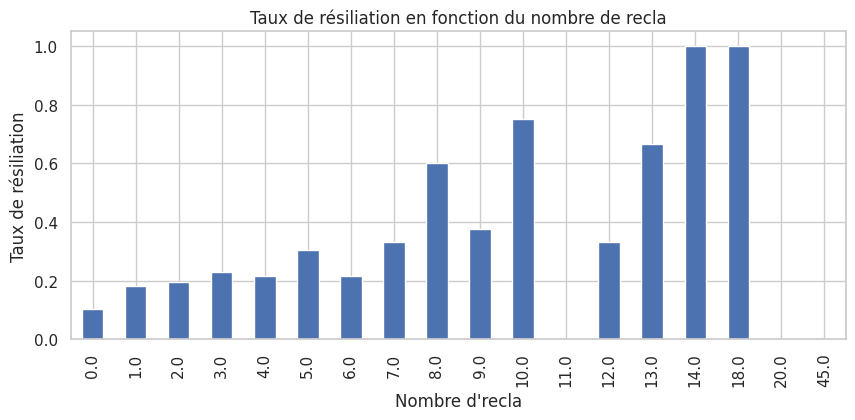

In [ ]:
taux_resiliation_par_interaction = (
    df_final.groupby('recla_nombre')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'recla")
plt.title("Taux de résiliation en fonction du nombre de recla")
plt.show()


In [ ]:
df_final['recla_nombre_bin'] = df_final['recla_nombre'].clip(upper=5)


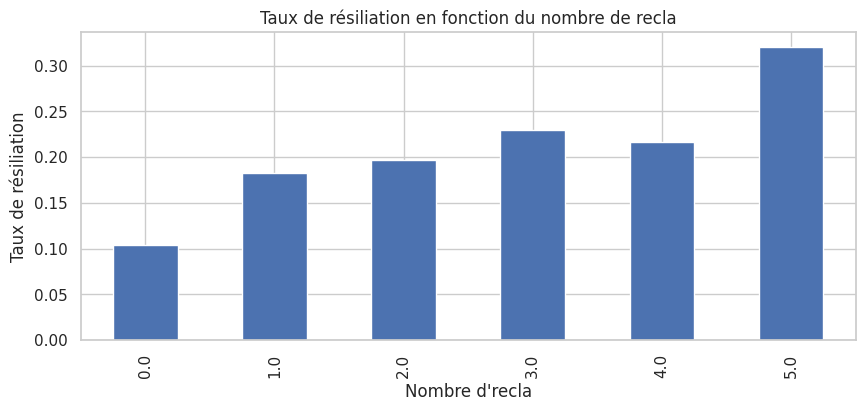

In [ ]:
taux_resiliation_par_interaction = (
    df_final.groupby('recla_nombre_bin')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'recla")
plt.title("Taux de résiliation en fonction du nombre de recla")
plt.show()


/tmp/ipykernel_4151/710355690.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


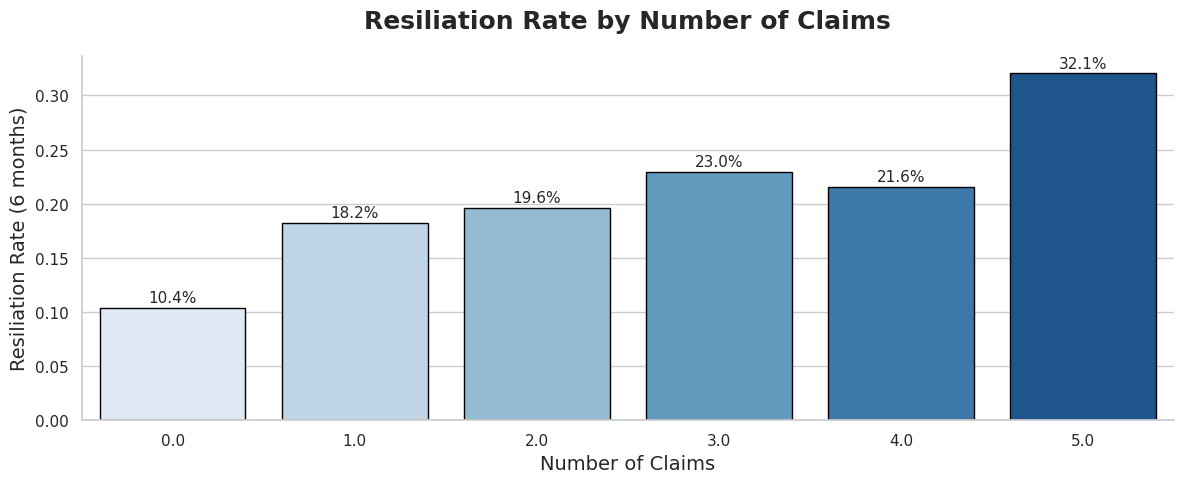

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul du taux de résiliation par nombre de réclamations
taux_resiliation_par_interaction = (
    df_final.groupby('recla_nombre_bin')['target_resiliation_6mois']
    .mean()
)

plt.figure(figsize=(12, 5))

# Barplot joli
ax = sns.barplot(
    x=taux_resiliation_par_interaction.index,
    y=taux_resiliation_par_interaction.values,
    palette="Blues",
    edgecolor="black"
)

# Titres et labels
plt.title("Resiliation Rate by Number of Claims", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Number of Claims", fontsize=14)
plt.ylabel("Resiliation Rate (6 months)", fontsize=14)

# Ajouter les étiquettes %
for i, v in enumerate(taux_resiliation_par_interaction.values):
    ax.text(
        i,
        v + 0.005,
        f"{v*100:.1f}%",
        ha='center',
        fontsize=11
    )

# Style propre
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
df_final['interaction_nb_total_bin'] = df_final['interaction_nb_total'].clip(upper=21)


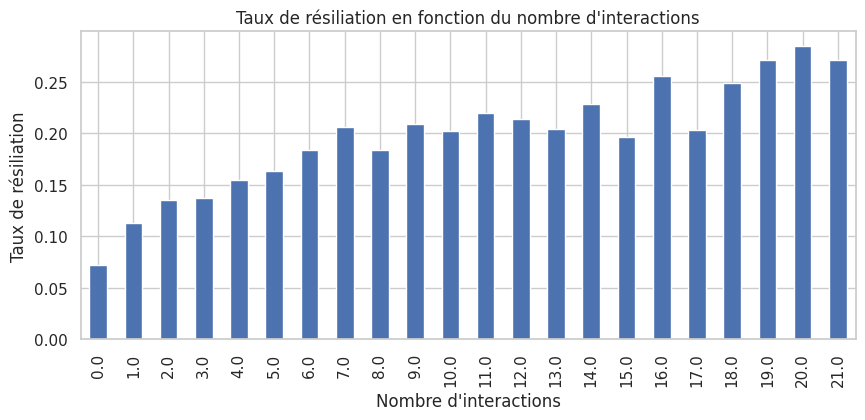

In [ ]:
taux_resiliation_par_interaction = (
    df_final.groupby('interaction_nb_total_bin')['target_resiliation_6mois']
    .mean()
)

taux_resiliation_par_interaction.plot(kind='bar', figsize=(10,4))

plt.ylabel("Taux de résiliation")
plt.xlabel("Nombre d'interactions")
plt.title("Taux de résiliation en fonction du nombre d'interactions")
plt.show()


In [ ]:
taux_resiliation_recla_sensible_resiliation = df_final.groupby('recla_sensible_resiliation').agg(
    nb_clients = ('target_resiliation_6mois', 'count'),
    taux_resiliation = ('target_resiliation_6mois', 'mean')
)

taux_resiliation_recla_sensible_resiliation

,nb_clients,taux_resiliation
recla_sensible_resiliation,,
0.0,132536,0.108944
1.0,38,0.289474
2.0,2,0.000000


In [ ]:
df_reclamations.shape

(11045, 12)

In [ ]:
df_reclamations.nunique()

client_code                7393
recla_date_reception        363
recla_date_cloture          301
recla_initiateur              5
recla_motif_acpr              5
recla_motif                  16
recla_theme                   5
recla_canal_entrant           6
recla_solution_trouvee        2
recla_reponse_gestion         2
recla_est_sensible            2
recla_motif_sensibilite       8
dtype: int64

In [ ]:
df_reclamations['recla_motif'].nunique()


16

/tmp/ipykernel_4151/3659747312.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


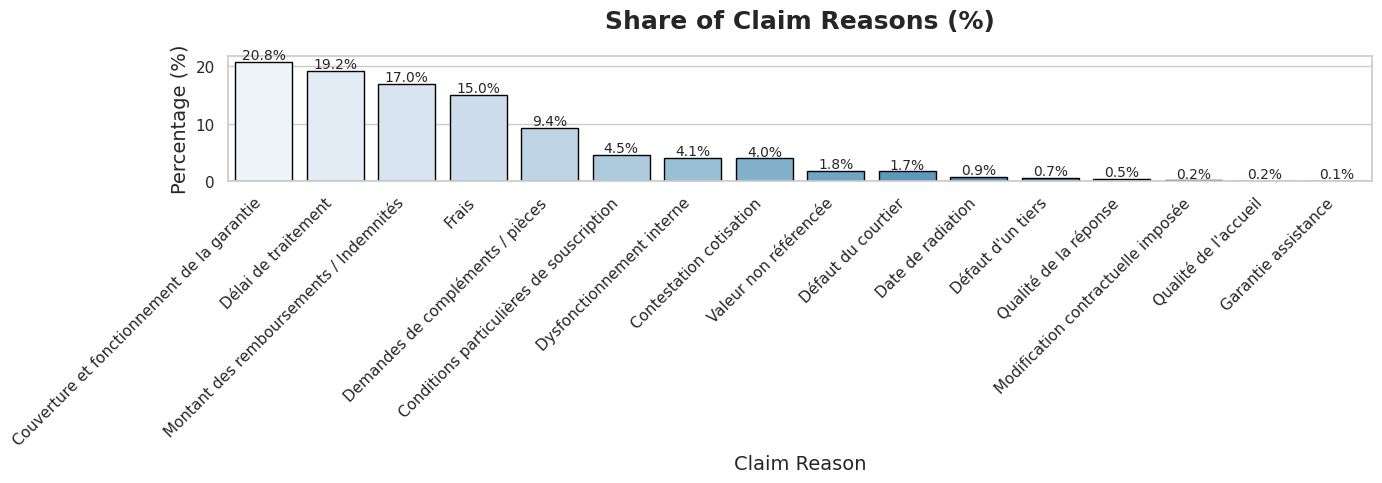

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul des parts (%)
motifs_pct = (
    df_reclamations['recla_motif']
    .value_counts(normalize=True) * 100
).sort_values(ascending=False)

plt.figure(figsize=(14, 5))

# 2. Bar plot
ax = sns.barplot(
    x=motifs_pct.index,
    y=motifs_pct.values,
    palette="Blues",
    edgecolor="black"
)

# 3. Titres & axes
plt.title("Share of Claim Reasons (%)", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Claim Reason", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

plt.xticks(rotation=45, ha="right", fontsize=11)

# 4. Ajouter les labels %
for i, v in enumerate(motifs_pct.values):
    ax.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


/tmp/ipykernel_4151/3472394637.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


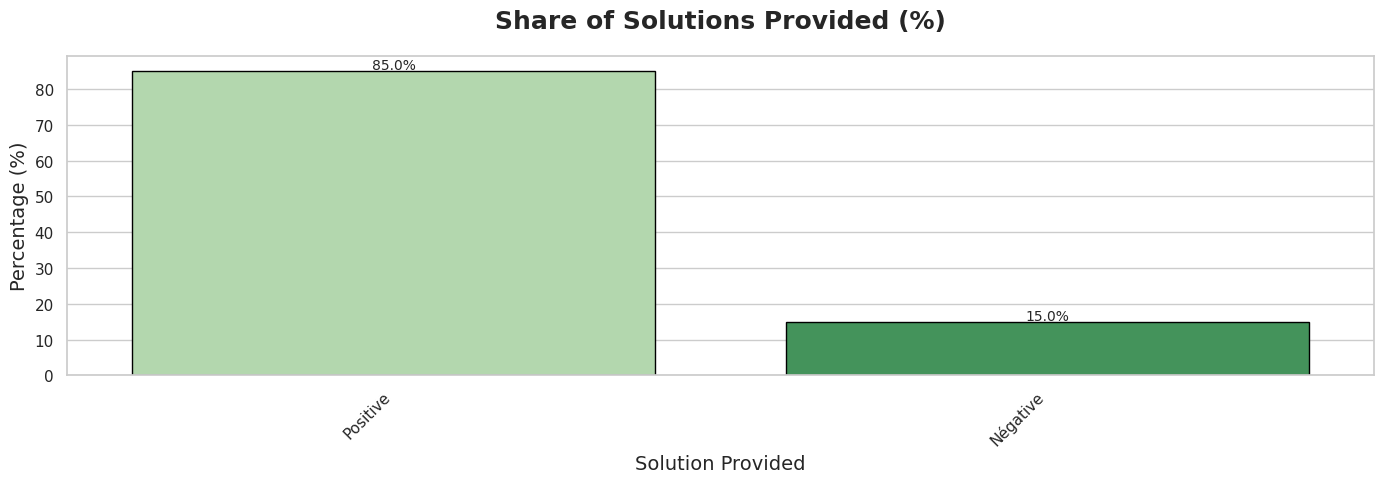

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul des parts (%) par solution
solution_pct = (
    df_reclamations['recla_solution_trouvee']
    .value_counts(normalize=True) * 100
).sort_values(ascending=False)

plt.figure(figsize=(14, 5))

# 2. Bar plot
ax = sns.barplot(
    x=solution_pct.index,
    y=solution_pct.values,
    palette="Greens",
    edgecolor="black"
)

# 3. Titres & axes
plt.title("Share of Solutions Provided (%)", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Solution Provided", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)

plt.xticks(rotation=45, ha="right", fontsize=11)

# 4. Labels %
for i, v in enumerate(solution_pct.values):
    ax.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()
